In [1]:
'''
14/05/26
QuickSearch_V2 returns numpy array of candidate target names.
Search done according to parameters in param.json.
Output is tagged with V2 by default.
'''
import time
import numpy as np
import glob, os, sys
import pandas as pd
%run ./asset.ipynb
%run ./width_depth.ipynb
import multiprocessing
import json, argparse


def _clean_token(x):
    if x is None:
        return None
    s = str(x).strip().lower()
    if not s:
        return None
    return s.replace(' ', '').replace('_', '').replace('-', '')


def dedup_candidates_by_v2_groups(cands, full_v2_path):
    """Deduplicate candidate names by merged V2 group IDs from full_metadata_V2.pkl."""
    if len(cands) == 0:
        return cands

    meta_v2 = pd.read_pickle(full_v2_path)
    name_cols = [c for c in ['Reduced', 'Sanitised', 'OBJECT', 'Object'] if c in meta_v2.columns]

    # token -> group id lookup
    lookup = {}
    for _, row in meta_v2.iterrows():
        gid = int(row['New Groups'])
        for c in name_cols:
            key = _clean_token(row[c])
            if key is not None and key not in lookup:
                lookup[key] = gid

    out = []
    seen_groups = set()
    unresolved = []

    for raw in cands.tolist():
        key = _clean_token(raw)
        gid = lookup.get(key)

        # Fallback through normalization regex rules loaded from grouping_V2 notebook logic
        if gid is None and key is not None and 'normalize_reduced' in globals():
            gid = lookup.get(_clean_token(normalize_reduced(key)))

        if gid is None:
            # Keep unresolved names to avoid accidental data loss
            unresolved.append(raw)
            out.append(raw)
            continue

        if gid in seen_groups:
            continue

        seen_groups.add(gid)
        out.append(raw)

    return np.array(out, dtype=object)


if __name__ == '__main__':
    startTime = time.time()

    parser = argparse.ArgumentParser(description='How to use QuickSearch_V2', epilog='ASSET by RBW')
    parser.add_argument('--p', metavar='param.json', default='param.json', help='parameter file name (default:param.json)')
    parser.add_argument('--nice', metavar='niceness', default=15, help='niceness of job (default: 15)')
    parser.add_argument('--line', metavar='line', default='K', help='define what atomic line to use (default: "K")')
    parser.add_argument('--r', metavar='res-path', default='../results/QuickSearch_V2/', help='output path (default: ../results/QuickSearch_V2/)')
    parser.add_argument('--tag', metavar='tag', default='V2', help='suffix tag for output filename (default: V2)')
    parser.add_argument('--groups-meta', default='/home/msp25gd/Downloads/res/meta/full_metadata_V2.pkl',
                        help='path to merged V2 full metadata (default: /home/msp25gd/Downloads/res/meta/full_metadata_V2.pkl)')
    parser.add_argument('--no-group-dedup', action='store_true',
                        help='disable deduplication by merged V2 groups')
    parser.add_argument('-f', '--f', dest='connection_file', default=None,
                        help='Jupyter kernel connection file')

    args = parser.parse_args()

    os.nice(int(args.nice))

    with open(args.p) as paramfile:
        param = json.load(paramfile)

    all_paths = glob.glob(param["dataset"] + '*/')

    min_spectra = int(param.get('min_spectra', 1))
    # Require a minimum number of spectra so each target has enough epochs to form a robust group reference.
    dataset_path = [p for p in all_paths if np.load(p + 'spec/sK.npy').shape[0] >= min_spectra]
    print('Stars with >= {} spectra: {}/{}'.format(min_spectra, len(dataset_path), len(all_paths)))

    Search = ASSET(parameters=param, line=args.line)

    def quicksearch_with_rv_filter(star):
        Search.ccf = False
        spec_param = Search.spec_analysis(star)
        if spec_param is None:
            return None

        new_spectra, med, med_err = spec_param

        if Search.ccf:
            rv_shift = Search.X_corr(med.copy())
            cond100 = (Search.radial_velocity > rv_shift - 50) & (Search.radial_velocity < rv_shift + 50)

        dip_detected = False
        max_peak_seen = -np.inf

        for i in range(len(new_spectra)):
            spec = new_spectra[i]

            snr = Search.snr(spec, med, Search.spectra_err[i], med_err)
            sd = np.std(snr)
            if not np.isfinite(sd) or sd == 0:
                continue

            corr_snr = snr.copy()
            if Search.ccf:
                corr_snr[cond100] = np.nan
            corr_snr = corr_snr[Search.snr_idxrange]

            sig = corr_snr / sd

            min_detect = np.nanmin(sig)
            max_detect = np.nanmax(sig)
            if np.isfinite(max_detect):
                max_peak_seen = max(max_peak_seen, float(max_detect))

            if min_detect < Search.threshold:
                width = Search.get_width(sig)
                if width >= Search.width_filter:
                    dip_detected = True

        if dip_detected:
            if not np.isfinite(max_peak_seen):
                max_peak_seen = np.nan
            return (str(Search.target_red), float(max_peak_seen))

        return None

    with multiprocessing.Pool(param["cores"]) as pool:
        out = pool.map(quicksearch_with_rv_filter, dataset_path)

    records = [item for item in out if item is not None]
    print('------------------')

    cands_raw = np.array([item[0] for item in records], dtype=object)
    peak_raw = np.array([item[1] for item in records], dtype=float)
    print('Raw candidates:', len(cands_raw))

    if args.no_group_dedup:
        cands = cands_raw
        print('Group dedup disabled')
    else:
        cands = dedup_candidates_by_v2_groups(cands_raw, args.groups_meta)
        print('After V2 group dedup:', len(cands), '(reduced by {})'.format(len(cands_raw) - len(cands)))

    # Map deduplicated names to peak values from the raw list
    peak_lookup = {}
    for name, peak in zip(cands_raw.tolist(), peak_raw.tolist()):
        if (name not in peak_lookup) or (np.isfinite(peak) and peak > peak_lookup[name]):
            peak_lookup[name] = peak

    cands_peak = np.array([peak_lookup.get(name, np.nan) for name in cands.tolist()], dtype=float)
    peak_threshold = abs(float(Search.threshold))

    # Split dip detections with significant positive peaks into requested bins
    bin_3p5_4_mask = (cands_peak >= peak_threshold) & (cands_peak < 4.0)
    bin_4_5_mask = (cands_peak >= 4.0) & (cands_peak < 5.0)
    bin_5_plus_mask = cands_peak >= 5.0

    peak_3p5_4 = cands[bin_3p5_4_mask]
    peak_4_5 = cands[bin_4_5_mask]
    peak_5_plus = cands[bin_5_plus_mask]

    print('Peak bins among candidates:')
    print('  +{:.1f} to +4 sigma: {}'.format(peak_threshold, len(peak_3p5_4)))
    print('  +4 to +5 sigma: {}'.format(len(peak_4_5)))
    print('  +5 sigma and above: {}'.format(len(peak_5_plus)))

    tag = args.tag.strip()
    if tag:
        cands_file = 'candidates_{}sig_{}cut_{}width_{}.npy'.format(Search.threshold, Search.cutoff, Search.width_filter, tag)
        peaks_file = 'candidate_max_peak_{}sig_{}cut_{}width_{}.npy'.format(Search.threshold, Search.cutoff, Search.width_filter, tag)
    else:
        cands_file = 'candidates_{}sig_{}cut_{}width.npy'.format(Search.threshold, Search.cutoff, Search.width_filter)
        peaks_file = 'candidate_max_peak_{}sig_{}cut_{}width.npy'.format(Search.threshold, Search.cutoff, Search.width_filter)

    if not os.path.exists(args.r):
        os.makedirs(args.r)
        print("new directory {} created!".format(args.r))

    np.save(args.r + cands_file, cands)
    np.save(args.r + peaks_file, cands_peak)

    peak_bin_dirs = {
        'peak_3p5_to_4': peak_3p5_4,
        'peak_4_to_5': peak_4_5,
        'peak_5_plus': peak_5_plus,
    }

    for folder, arr in peak_bin_dirs.items():
        out_dir = os.path.join(args.r, folder)
        os.makedirs(out_dir, exist_ok=True)
        np.save(os.path.join(out_dir, 'targets.npy'), arr)

    executionTime = (time.time() - startTime)
    print('Execution time in seconds: ' + str(executionTime))

Stars with >= 3 spectra: 2888/12828
[ngc280846422] not enough spectra for the search after cutting noisy spectra!


/tmp/ipykernel_275397/4253543805.py:268: RuntimeWarning: invalid value encountered in divide
  norm_s[i,:] = spec/mean


[smcwr2] not enough spectra for the search after cutting noisy spectra!
[toobulgedwarfi] not enough spectra for the search after cutting noisy spectra!
[q23570048] not enough spectra for the search after cutting noisy spectra!
[q2059360] not enough spectra for the search after cutting noisy spectra!
[blg41] not enough spectra for the search after cutting noisy spectra!
[novasco94] not enough spectra for the search after cutting noisy spectra!
[sgr105] not enough spectra for the search after cutting noisy spectra!
[png007.5+04.3] not enough spectra for the search after cutting noisy spectra!
[tha1526] not enough spectra for the search after cutting noisy spectra!
[tha1530] not enough spectra for the search after cutting noisy spectra!
[q12490159] not enough spectra for the search after cutting noisy spectra!
[wd2241325] not enough spectra for the search after cutting noisy spectra!
[sextans1104] not enough spectra for the search after cutting noisy spectra!
[lmcn19] not enough spectra f

/tmp/ipykernel_275397/4253543805.py:268: RuntimeWarning: invalid value encountered in divide
  norm_s[i,:] = spec/mean


[ltt3864] not enough spectra for the search after cutting noisy spectra!
[quintet1] not enough spectra for the search after cutting noisy spectra!
[1130+0411] not enough spectra for the search after cutting noisy spectra!
[gc8] not enough spectra for the search after cutting noisy spectra!
[ex1109] not enough spectra for the search after cutting noisy spectra!
[sdssj1425+0827] not enough spectra for the search after cutting noisy spectra!
[j115538+053050] not enough spectra for the search after cutting noisy spectra!
[b0227369] not enough spectra for the search after cutting noisy spectra!
[1048147395606] not enough spectra for the search after cutting noisy spectra!


...

[smcwr4] not enough spectra for the search after cutting noisy spectra!


/tmp/ipykernel_275397/4253543805.py:268: RuntimeWarning: invalid value encountered in divide
  norm_s[i,:] = spec/mean


[hen2131] not enough spectra for the search after cutting noisy spectra!
[m35obj] not enough spectra for the search after cutting noisy spectra!
[lsrcra1] not enough spectra for the search after cutting noisy spectra!
[imnor] not enough spectra for the search after cutting noisy spectra!
[qsoj1018+0548] not enough spectra for the search after cutting noisy spectra!
[sdssj0957+0610] not enough spectra for the search after cutting noisy spectra!
[lmccep2471] not enough spectra for the search after cutting noisy spectra!
[j1456+1609] not enough spectra for the search after cutting noisy spectra!
[sculptor1446] not enough spectra for the search after cutting noisy spectra!
[v745sco] not enough spectra for the search after cutting noisy spectra!
[fornaxet0141] not enough spectra for the search after cutting noisy spectra!
[esoha574] not enough spectra for the search after cutting noisy spectra!
[jw558] not enough spectra for the search after cutting noisy spectra!
[j1456+0407] not enough sp

/tmp/ipykernel_275397/4253543805.py:268: RuntimeWarning: invalid value encountered in divide
  norm_s[i,:] = spec/mean


[ltt9293] not enough spectra for the search after cutting noisy spectra!
[cvso17] not enough spectra for the search after cutting noisy spectra!
[j053253.22-695915.4] not enough spectra for the search after cutting noisy spectra!
[sdssj14390106] not enough spectra for the search after cutting noisy spectra!
[source6563584900242906624] not enough spectra for the search after cutting noisy spectra!
[j0839+1112] not enough spectra for the search after cutting noisy spectra!
[m794] not enough spectra for the search after cutting noisy spectra!
[vhs1256a] not enough spectra for the search after cutting noisy spectra!
[mrc0200+015] not enough spectra for the search after cutting noisy spectra!
[j044920.32-690900.0] not enough spectra for the search after cutting noisy spectra!
[lehpm494] not enough spectra for the search after cutting noisy spectra!
[qsob1202074] not enough spectra for the search after cutting noisy spectra!
[wd1w243] not enough spectra for the search after cutting noisy spe

In [2]:
print('QuickSearch_V2 candidates:', len(cands))
print('Output file:', cands_file)

QuickSearch_V2 candidates: 498
Output file: candidates_-3.5sig_1.5cut_2width_V2.npy


In [3]:
# Diagnose merge-aware dedup impact on current candidate list
import os

def _norm_name_for_merge(name):
    # reuse notebook normalization if available
    if 'normalize_reduced' in globals():
        return normalize_reduced(str(name).strip().lower())
    return str(name).strip().lower()

cands_list = [str(x) for x in cands.tolist()]
norm = [_norm_name_for_merge(x) for x in cands_list]

print('Raw candidates:', len(cands_list))
print('Unique by normalized name:', len(set(norm)))
print('Potential reductions:', len(cands_list) - len(set(norm)))

# show collisions (names that collapse to same normalized key)
from collections import defaultdict
bucket = defaultdict(list)
for raw, n in zip(cands_list, norm):
    bucket[n].append(raw)
collisions = {k:v for k,v in bucket.items() if len(set(v)) > 1}
print('Colliding keys:', len(collisions))
for i, (k, v) in enumerate(collisions.items()):
    if i >= 15:
        break
    print(' ', k, '=>', sorted(set(v)))

Raw candidates: 498
Unique by normalized name: 498
Potential reductions: 0
Colliding keys: 0


In [4]:
# Diagnose group-aware dedup against V2 merged metadata
import pandas as pd

full_v2_path = '/home/msp25gd/Downloads/res/meta/full_metadata_V2.pkl'
meta_v2 = pd.read_pickle(full_v2_path)

# Build lookup from any known name token -> merged group id
# Use multiple columns because folder names can come from different naming conventions.
def _clean_token(x):
    if x is None:
        return None
    s = str(x).strip().lower()
    if not s:
        return None
    s = s.replace(' ', '').replace('_', '').replace('-', '')
    return s

name_cols = [c for c in ['Reduced', 'Sanitised', 'OBJECT', 'Object'] if c in meta_v2.columns]
lookup = {}
for _, row in meta_v2.iterrows():
    gid = int(row['New Groups'])
    for c in name_cols:
        key = _clean_token(row[c])
        if key is not None and key not in lookup:
            lookup[key] = gid

resolved = 0
unresolved = 0
groups_seen = set()
for raw in cands.tolist():
    key = _clean_token(raw)
    gid = lookup.get(key)
    if gid is None and key is not None and 'normalize_reduced' in globals():
        gid = lookup.get(_clean_token(normalize_reduced(key)))
    if gid is None:
        unresolved += 1
    else:
        resolved += 1
        groups_seen.add(gid)

print('Raw candidates:', len(cands))
print('Resolved to V2 groups:', resolved)
print('Unresolved:', unresolved)
print('Unique V2 groups among resolved candidates:', len(groups_seen))
if resolved > 0:
    print('Potential reduction (resolved only):', resolved - len(groups_seen))

Raw candidates: 498
Resolved to V2 groups: 498
Unresolved: 0
Unique V2 groups among resolved candidates: 498
Potential reduction (resolved only): 0


In [5]:
# Spectral-type readiness assessment for HR diagram construction.
import os
import numpy as np
import pandas as pd
from astroquery.simbad import Simbad

# Resolve candidate list from current runtime or latest saved QuickSearch output.
if 'cands' in globals() and cands is not None and len(cands) > 0:
    candidate_names_hr = [str(x) for x in np.array(cands, dtype=object).tolist()]
    candidate_source_hr = 'runtime:cands'
else:
    candidate_dirs_hr = [
        '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2',
        '/home/msp25gd/ResearchProjectMSc/ResolutionHandling/QuickSearch_V2',
        '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch',
    ]
    candidate_files_hr = []
    for d in candidate_dirs_hr:
        if os.path.isdir(d):
            for f in os.listdir(d):
                if f.startswith('candidates') and f.endswith('.npy'):
                    candidate_files_hr.append(os.path.join(d, f))

    if len(candidate_files_hr) == 0:
        raise FileNotFoundError('No candidate .npy file found for spectral-type assessment.')

    latest_file_hr = max(candidate_files_hr, key=os.path.getmtime)
    candidate_names_hr = [str(x) for x in np.load(latest_file_hr, allow_pickle=True).tolist()]
    candidate_source_hr = latest_file_hr

# Keep order + unique.
seen_hr = set()
candidate_names_hr = [x for x in candidate_names_hr if not (x in seen_hr or seen_hr.add(x))]

# Load metadata rows for these targets.
metadata_path_hr = '/home/msp25gd/Downloads/res/meta/metadata.pkl'
meta_hr = pd.read_pickle(metadata_path_hr)
reduced_col_hr = 'Reduced' if 'Reduced' in meta_hr.columns else ('reduced' if 'reduced' in meta_hr.columns else None)
if reduced_col_hr is None:
    raise KeyError('Reduced/reduced column missing in metadata.pkl')

candidate_key_set_hr = {x.lower() for x in candidate_names_hr}
meta_match_hr = meta_hr[meta_hr[reduced_col_hr].astype(str).str.lower().isin(candidate_key_set_hr)].copy()

# Preferred object-name column for Simbad queries.
object_col_hr = None
for col in ['OBJECT', 'Object', 'Sanitised', 'sanitised', reduced_col_hr]:
    if col in meta_match_hr.columns:
        object_col_hr = col
        break
if object_col_hr is None:
    raise KeyError('Could not resolve an object-name column for Simbad queries.')

# Check if spectral type already exists in metadata.
sp_cols_hr = [c for c in ['sp_type', 'SP_TYPE', 'spectral_type', 'SpectralType'] if c in meta_match_hr.columns]
meta_with_sp_hr = 0
if len(sp_cols_hr) > 0:
    first_sp_col_hr = sp_cols_hr[0]
    meta_with_sp_hr = int(
        meta_match_hr[first_sp_col_hr].astype(str).str.strip().replace({'': np.nan, 'None': np.nan, '--': np.nan, 'nan': np.nan}).notna().sum()
    )

# Query Simbad for spectral type (sample-based readiness check).
sample_limit_hr = min(200, len(meta_match_hr))
query_df_hr = meta_match_hr[[reduced_col_hr, object_col_hr]].head(sample_limit_hr).copy()

simbad_hr = Simbad()
simbad_hr.add_votable_fields('sp_type')
simbad_hr.TIMEOUT = 90

resolved_rows_hr = []
not_found_hr = 0
errors_hr = 0

for i_hr, (_, row_hr) in enumerate(query_df_hr.iterrows(), start=1):
    reduced_name_hr = str(row_hr[reduced_col_hr])
    object_name_hr = str(row_hr[object_col_hr])
    try:
        result_hr = simbad_hr.query_object(object_name_hr)
        if result_hr is not None and len(result_hr) > 0 and 'sp_type' in result_hr.colnames:
            sp_hr = str(result_hr['sp_type'][0]).strip()
            if sp_hr not in ['', 'None', '--', 'nan']:
                resolved_rows_hr.append({'Reduced': reduced_name_hr, 'ObjectQuery': object_name_hr, 'sp_type': sp_hr})
            else:
                not_found_hr += 1
        else:
            not_found_hr += 1
    except Exception:
        errors_hr += 1

    if (i_hr % 25 == 0) or (i_hr == sample_limit_hr):
        print(f'Queried {i_hr}/{sample_limit_hr} | resolved: {len(resolved_rows_hr)} | not_found: {not_found_hr} | errors: {errors_hr}')

resolved_sample_hr = len(resolved_rows_hr)
sample_coverage_hr = (100.0 * resolved_sample_hr / sample_limit_hr) if sample_limit_hr > 0 else 0.0
metadata_coverage_hr = (100.0 * meta_with_sp_hr / len(meta_match_hr)) if len(meta_match_hr) > 0 else 0.0

print('\n=== Spectral-Type Readiness Summary ===')
print(f'Candidate source: {candidate_source_hr}')
print(f'Unique candidates considered: {len(candidate_names_hr)}')
print(f'Candidates matched in metadata: {len(meta_match_hr)}')
print(f'Metadata spectral-type coverage: {meta_with_sp_hr}/{len(meta_match_hr)} ({metadata_coverage_hr:.1f}%)')
print(f'Simbad sample query coverage: {resolved_sample_hr}/{sample_limit_hr} ({sample_coverage_hr:.1f}%)')

if sample_coverage_hr >= 70.0 or metadata_coverage_hr >= 70.0:
    print('Assessment: READY to build an HR diagram with spectral-type classes for most stars.')
elif sample_coverage_hr >= 40.0 or metadata_coverage_hr >= 40.0:
    print('Assessment: PARTIALLY READY; HR diagram is feasible but will include many unknown spectral types.')
else:
    print('Assessment: LOW READINESS for spectral-type-based HR classes from current sources.')

spectral_type_assessment_hr = pd.DataFrame(resolved_rows_hr)
if len(spectral_type_assessment_hr) > 0:
    display(spectral_type_assessment_hr.head(20))

Queried 25/200 | resolved: 14 | not_found: 11 | errors: 0
Queried 50/200 | resolved: 36 | not_found: 14 | errors: 0
Queried 75/200 | resolved: 58 | not_found: 17 | errors: 0
Queried 100/200 | resolved: 71 | not_found: 29 | errors: 0
Queried 125/200 | resolved: 89 | not_found: 36 | errors: 0
Queried 150/200 | resolved: 107 | not_found: 43 | errors: 0
Queried 175/200 | resolved: 120 | not_found: 55 | errors: 0
Queried 200/200 | resolved: 134 | not_found: 66 | errors: 0

=== Spectral-Type Readiness Summary ===
Candidate source: runtime:cands
Unique candidates considered: 498
Candidates matched in metadata: 6280
Metadata spectral-type coverage: 0/6280 (0.0%)
Simbad sample query coverage: 134/200 (67.0%)
Assessment: PARTIALLY READY; HR diagram is feasible but will include many unknown spectral types.


,Reduced,ObjectQuery,sp_type
0,jl277,JL 277,sdB+G
1,he04302457,HE 0430-2457,sdB(+F?)
2,pg0048+091,PG 0048+091,sdOB+F5V
3,hd93129a,HD93129A,O2If*
4,he04302457,HE 0430-2457,sdB(+F?)
5,pg1514+034,PG 1514+034,sdOB+G1V
6,ec123003224,EC12300-3224,sdB+
7,hd93129a,HD93129A,O2If*
8,hd93129a,HD93129A,O2If*
9,hd93129a,HD93129A,O2If*


In [4]:
# Build identified/unidentified group lists by spectral-type availability.
import os
import re
import numpy as np
import pandas as pd
from astroquery.simbad import Simbad

# 1) Create list with all groups from current quicksearch output.
if 'cands' in globals() and cands is not None and len(cands) > 0:
    all_groups_resFirst = [str(x) for x in np.array(cands, dtype=object).tolist()]
    groups_source_resFirst = 'runtime:cands'
else:
    candidate_dirs_resFirst = [
        '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2',
        '/home/msp25gd/ResearchProjectMSc/ResolutionHandling/QuickSearch_V2',
        '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch',
    ]
    candidate_files_resFirst = []
    for d in candidate_dirs_resFirst:
        if os.path.isdir(d):
            for f in os.listdir(d):
                if f.startswith('candidates') and f.endswith('.npy'):
                    candidate_files_resFirst.append(os.path.join(d, f))

    if len(candidate_files_resFirst) == 0:
        raise FileNotFoundError('No candidate files found to build group list.')

    latest_candidates_resFirst = max(candidate_files_resFirst, key=os.path.getmtime)
    all_groups_resFirst = [str(x) for x in np.load(latest_candidates_resFirst, allow_pickle=True).tolist()]
    groups_source_resFirst = latest_candidates_resFirst

# Keep original order and remove duplicates.
seen_groups_resFirst = set()
all_groups_resFirst = [g for g in all_groups_resFirst if not (g in seen_groups_resFirst or seen_groups_resFirst.add(g))]

# 2) Try to get spectral type from metadata first, then Simbad.
metadata_path_resFirst = '/home/msp25gd/Downloads/res/meta/metadata.pkl'
meta_resFirst = pd.read_pickle(metadata_path_resFirst)
reduced_col_resFirst = 'Reduced' if 'Reduced' in meta_resFirst.columns else ('reduced' if 'reduced' in meta_resFirst.columns else None)
if reduced_col_resFirst is None:
    raise KeyError('Reduced/reduced column not found in metadata.')

object_col_resFirst = None
for col in ['OBJECT', 'Object', 'Sanitised', 'sanitised', reduced_col_resFirst]:
    if col in meta_resFirst.columns:
        object_col_resFirst = col
        break
if object_col_resFirst is None:
    raise KeyError('No usable object-name column found for spectral-type lookup.')

sp_cols_resFirst = [c for c in ['sp_type', 'SP_TYPE', 'spectral_type', 'SpectralType'] if c in meta_resFirst.columns]
sp_col_resFirst = sp_cols_resFirst[0] if len(sp_cols_resFirst) > 0 else None

meta_group_rows_resFirst = meta_resFirst[
    meta_resFirst[reduced_col_resFirst].astype(str).str.lower().isin({g.lower() for g in all_groups_resFirst})
]

# Representative row per group for object-name query.
group_repr_resFirst = meta_group_rows_resFirst.groupby(reduced_col_resFirst, as_index=False).first()

simbad_resFirst = Simbad()
simbad_resFirst.add_votable_fields('sp_type')
simbad_resFirst.TIMEOUT = 90

def _clean_sp_resFirst(x):
    if x is None:
        return None
    s = str(x).strip()
    if s in ['', 'None', '--', 'nan']:
        return None
    return s

def _main_spectral_type_resFirst(sp):
    sp_clean = _clean_sp_resFirst(sp)
    if sp_clean is None:
        return 'Unknown'
    match = re.search(r'[OBAFGKMWCSLTRY]', sp_clean.upper())
    if not match:
        return 'Unknown'
    return f"{match.group(0)}-type"

identified_records_resFirst = []
unidentified_groups_resFirst = list(all_groups_resFirst)
identified_groups_resFirst = []

for i_resFirst, group_name_resFirst in enumerate(all_groups_resFirst, start=1):
    row_match_resFirst = group_repr_resFirst[
        group_repr_resFirst[reduced_col_resFirst].astype(str).str.lower() == group_name_resFirst.lower()
    ]
    if len(row_match_resFirst) == 0:
        continue

    row_resFirst = row_match_resFirst.iloc[0]
    object_name_resFirst = str(row_resFirst[object_col_resFirst])

    sp_full_resFirst = None

    # Fast path: already in metadata.
    if sp_col_resFirst is not None and sp_col_resFirst in row_resFirst.index:
        sp_full_resFirst = _clean_sp_resFirst(row_resFirst[sp_col_resFirst])

    # Fallback: Simbad query.
    if sp_full_resFirst is None:
        try:
            result_resFirst = simbad_resFirst.query_object(object_name_resFirst)
            if result_resFirst is not None and len(result_resFirst) > 0 and 'sp_type' in result_resFirst.colnames:
                sp_full_resFirst = _clean_sp_resFirst(result_resFirst['sp_type'][0])
        except Exception:
            sp_full_resFirst = None

    if sp_full_resFirst is not None:
        identified_groups_resFirst.append(group_name_resFirst)
        if group_name_resFirst in unidentified_groups_resFirst:
            unidentified_groups_resFirst.remove(group_name_resFirst)
        identified_records_resFirst.append({
            'Star': group_name_resFirst,
            'SpectralTypeFull': sp_full_resFirst,
            'SpectralTypeMain': _main_spectral_type_resFirst(sp_full_resFirst),
            'Tag': 'identified',
        })

    if (i_resFirst % 25 == 0) or (i_resFirst == len(all_groups_resFirst)):
        print(
            f"Processed {i_resFirst}/{len(all_groups_resFirst)} | "
            f"identified: {len(identified_groups_resFirst)} | "
            f"unidentified: {len(unidentified_groups_resFirst)}"
        )

identified_table_resFirst = pd.DataFrame(identified_records_resFirst).sort_values(
    by=['SpectralTypeMain', 'Star'], ascending=[True, True]
).reset_index(drop=True)

print('\n=== Spectral-Type Identification Summary ===')
print(f'Groups source: {groups_source_resFirst}')
print(f'Total groups: {len(all_groups_resFirst)}')
print(f'Identified groups: {len(identified_groups_resFirst)}')
print(f'Unidentified groups: {len(unidentified_groups_resFirst)}')

if len(identified_table_resFirst) > 0:
    display(identified_table_resFirst.head(50))
else:
    print('No identified spectral types found.')

Processed 25/498 | identified: 14 | unidentified: 484


Processed 50/498 | identified: 27 | unidentified: 471


Processed 75/498 | identified: 40 | unidentified: 458


Processed 100/498 | identified: 49 | unidentified: 449


Processed 125/498 | identified: 61 | unidentified: 437


...

Processed 425/498 | identified: 197 | unidentified: 301


Processed 450/498 | identified: 211 | unidentified: 287


Processed 475/498 | identified: 224 | unidentified: 274


Processed 498/498 | identified: 238 | unidentified: 260

=== Spectral-Type Identification Summary ===
Groups source: /home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width_V2_resFirst_rerun_resFirst_rerun_resFirst_rerun_resFirst_rerun.npy
Total groups: 498
Identified groups: 238
Unidentified groups: 260


,Star,SpectralTypeFull,SpectralTypeMain,Tag
0,betpic,A6V,A-type,identified
1,eg21,DA3.0,A-type,identified
2,hd10638,A3,A-type,identified
3,hd111133,A0VspSrCrEu,A-type,identified
4,hd11753,A3V,A-type,identified
5,hd125248,ApSi(Cr),A-type,identified
6,hd15130,A0V,A-type,identified
7,hd39060,A6V,A-type,identified
8,hd48915,A0mA1Va,A-type,identified
9,hd50241,A8VnkA6,A-type,identified


In [11]:
# Solution 1: aggressive name-variant lookup for currently unidentified groups.
# This cell only processes unidentified groups and appends newly-resolved stars
# into identified_table_resFirst while removing them from unidentified_groups_resFirst.

import re
import numpy as np
import pandas as pd
from astroquery.simbad import Simbad

required_vars = [
    'unidentified_groups_resFirst',
    'identified_groups_resFirst',
    'identified_table_resFirst',
    'meta_resFirst',
    'reduced_col_resFirst',
    'object_col_resFirst',
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(
        f'Missing required variables: {missing_vars}. Run Cell 6 first (identified/unidentified builder).'
    )

# Reuse helpers from Cell 6 if already defined.
if '_clean_sp_resFirst' not in globals():
    def _clean_sp_resFirst(x):
        if x is None:
            return None
        s = str(x).strip()
        if s in ['', 'None', '--', 'nan']:
            return None
        return s

if '_main_spectral_type_resFirst' not in globals():
    def _main_spectral_type_resFirst(sp):
        sp_clean = _clean_sp_resFirst(sp)
        if sp_clean is None:
            return 'Unknown'
        match = re.search(r'[OBAFGKMWCSLTRY]', sp_clean.upper())
        if not match:
            return 'Unknown'
        return f"{match.group(0)}-type"

simbad_sol1 = Simbad()
simbad_sol1.add_votable_fields('sp_type')
simbad_sol1.TIMEOUT = 90


def _norm_name_sol1(name):
    return str(name).strip()


def _name_variants_sol1(name):
    """Generate plausible catalog-style aliases from a reduced/object name."""
    n = _norm_name_sol1(name)
    n_low = n.lower()

    variants = []

    def _add(x):
        x = _norm_name_sol1(x)
        if x and x not in variants:
            variants.append(x)

    # Raw forms first.
    _add(n)
    _add(n.upper())
    _add(n.replace('_', ' '))
    _add(n.replace('_', ''))

    # Common catalog patterns.
    m = re.match(r'^hd\s*([0-9]+)$', n_low)
    if m:
        num = m.group(1)
        _add(f'HD {num}')
        _add(f'HD{num}')

    m = re.match(r'^hr\s*([0-9]+)$', n_low)
    if m:
        num = m.group(1)
        _add(f'HR {num}')
        _add(f'HR{num}')

    m = re.match(r'^hip\s*([0-9]+)$', n_low)
    if m:
        num = m.group(1)
        _add(f'HIP {num}')
        _add(f'HIP{num}')

    m = re.match(r'^tic\s*([0-9]+)$', n_low)
    if m:
        num = m.group(1)
        _add(f'TIC {num}')
        _add(f'TIC{num}')

    m = re.match(r'^toi\s*([0-9]+)$', n_low)
    if m:
        num = m.group(1)
        _add(f'TOI {num}')
        _add(f'TOI-{num}')

    # 2MASS naming variants.
    m = re.match(r'^2massj?([0-9]{6,}[+-][0-9]{6,})$', n_low)
    if m:
        body = m.group(1).upper()
        _add(f'2MASS J{body}')
        _add(f'2MASSJ{body}')
        _add(f'J{body}')

    # BD/CD style variants.
    for prefix in ['bd', 'cd']:
        m = re.match(rf'^{prefix}[\s-]*([0-9]+)([0-9]{{2,}})$', n_low)
        if m:
            a, b = m.group(1), m.group(2)
            _add(f"{prefix.upper()}-{a} {b}")
            _add(f"{prefix.upper()}-{a}{b}")

    # WD pattern: try plus and minus if sign is absent in reduced name.
    m = re.match(r'^wd\s*([0-9]{4})([0-9]{3,4})$', n_low)
    if m:
        a, b = m.group(1), m.group(2)
        _add(f'WD {a}+{b}')
        _add(f'WD {a}-{b}')
        _add(f'WD{a}+{b}')
        _add(f'WD{a}-{b}')

    return variants


def _query_sp_type_with_aliases_sol1(candidates, max_queries=18):
    """Try aliases one by one; return first successful sp_type and alias used."""
    queried = 0
    for alias in candidates:
        if queried >= max_queries:
            break
        queried += 1
        try:
            result = simbad_sol1.query_object(alias)
            if result is not None and len(result) > 0 and 'sp_type' in result.colnames:
                sp = _clean_sp_resFirst(result['sp_type'][0])
                if sp is not None:
                    return sp, alias
        except Exception:
            continue
    return None, None


new_rows_sol1 = []
resolved_count_sol1 = 0
start_unidentified_sol1 = len(unidentified_groups_resFirst)

# Work on a snapshot to allow safe in-place removals.
for idx_sol1, group_name_sol1 in enumerate(list(unidentified_groups_resFirst), start=1):
    row_match_sol1 = meta_resFirst[
        meta_resFirst[reduced_col_resFirst].astype(str).str.lower() == str(group_name_sol1).lower()
    ]

    candidate_names_sol1 = []

    # Include metadata object names for this group.
    if len(row_match_sol1) > 0:
        for _, r in row_match_sol1.iterrows():
            for col in [object_col_resFirst, reduced_col_resFirst, 'Sanitised', 'sanitised', 'OBJECT', 'Object']:
                if col in r.index:
                    val = str(r[col]).strip()
                    if val and val not in ['None', 'nan']:
                        candidate_names_sol1.append(val)

    # Always include group name itself.
    candidate_names_sol1.append(str(group_name_sol1))

    # Expand aliases.
    alias_candidates_sol1 = []
    for name_sol1 in candidate_names_sol1:
        for alias_sol1 in _name_variants_sol1(name_sol1):
            if alias_sol1 not in alias_candidates_sol1:
                alias_candidates_sol1.append(alias_sol1)

    sp_found_sol1, alias_used_sol1 = _query_sp_type_with_aliases_sol1(alias_candidates_sol1, max_queries=18)

    if sp_found_sol1 is not None:
        resolved_count_sol1 += 1
        if group_name_sol1 not in identified_groups_resFirst:
            identified_groups_resFirst.append(group_name_sol1)
        if group_name_sol1 in unidentified_groups_resFirst:
            unidentified_groups_resFirst.remove(group_name_sol1)

        new_rows_sol1.append(
            {
                'Star': group_name_sol1,
                'SpectralTypeFull': sp_found_sol1,
                'SpectralTypeMain': _main_spectral_type_resFirst(sp_found_sol1),
                'Tag': 'identified',
                'LookupAlias': alias_used_sol1,
                'Method': 'solution1_name_variants',
            }
        )

    if (idx_sol1 % 20 == 0) or (idx_sol1 == start_unidentified_sol1):
        print(
            f"Solution 1 progress {idx_sol1}/{start_unidentified_sol1} | "
            f"newly resolved: {resolved_count_sol1} | "
            f"remaining unidentified: {len(unidentified_groups_resFirst)}"
        )

# Merge into identified table.
if len(new_rows_sol1) > 0:
    add_df_sol1 = pd.DataFrame(new_rows_sol1)
    identified_table_resFirst = pd.concat([identified_table_resFirst, add_df_sol1], ignore_index=True)
    identified_table_resFirst = identified_table_resFirst.drop_duplicates(subset=['Star'], keep='first')
    identified_table_resFirst = identified_table_resFirst.sort_values(
        by=['SpectralTypeMain', 'Star'], ascending=[True, True]
    ).reset_index(drop=True)

print('\n=== Solution 1 Summary ===')
print(f'Initially unidentified: {start_unidentified_sol1}')
print(f'Newly resolved this pass: {resolved_count_sol1}')
print(f'Identified total now: {len(identified_groups_resFirst)}')
print(f'Unidentified remaining: {len(unidentified_groups_resFirst)}')

if len(new_rows_sol1) > 0:
    display(pd.DataFrame(new_rows_sol1).head(50))
else:
    print('No new spectral types found in this pass.')


Solution 1 progress 20/2473 | newly resolved: 6 | remaining unidentified: 2467


Solution 1 progress 40/2473 | newly resolved: 9 | remaining unidentified: 2464


Solution 1 progress 60/2473 | newly resolved: 15 | remaining unidentified: 2458


Solution 1 progress 80/2473 | newly resolved: 23 | remaining unidentified: 2450


Solution 1 progress 100/2473 | newly resolved: 34 | remaining unidentified: 2439


...

Solution 1 progress 2420/2473 | newly resolved: 1048 | remaining unidentified: 1425


Solution 1 progress 2440/2473 | newly resolved: 1054 | remaining unidentified: 1419


Solution 1 progress 2460/2473 | newly resolved: 1060 | remaining unidentified: 1413


Solution 1 progress 2473/2473 | newly resolved: 1063 | remaining unidentified: 1410

=== Solution 1 Summary ===
Initially unidentified: 2473
Newly resolved this pass: 1063
Identified total now: 1477
Unidentified remaining: 1410


,Star,SpectralTypeFull,SpectralTypeMain,Tag,LookupAlias,Method
0,betapictoris,A6V,A-type,identified,beta Pictoris,solution1_name_variants
1,wasp7,F5V,F-type,identified,WASP-7,solution1_name_variants
2,sn1987a,SNIIpec,S-type,identified,SN 1987A,solution1_name_variants
3,aeaqr,K3-5IV/V,K-type,identified,AE_Aqr,solution1_name_variants
4,hd98800,K5V(e),K-type,identified,HD 98800,solution1_name_variants
5,l2pup,M5IIIe,M-type,identified,L2_Pup,solution1_name_variants
6,hd224974,G0V,G-type,identified,HD 224974,solution1_name_variants
7,hd70937,F5V,F-type,identified,HD 70937,solution1_name_variants
8,hd76700,G6V,G-type,identified,HD76700,solution1_name_variants
9,hd41255,F8/G0V,F-type,identified,HD 41255,solution1_name_variants


In [12]:
# Solution 2: coordinate-based spectral-type recovery for remaining unidentified groups.
# Strategy: use metadata RA/Dec, query SIMBAD by region, and take nearest object with a valid sp_type.

import re
import numpy as np
import pandas as pd
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord
import astropy.units as u

required_vars_sol2 = [
    'unidentified_groups_resFirst',
    'identified_groups_resFirst',
    'identified_table_resFirst',
    'meta_resFirst',
    'reduced_col_resFirst',
]
missing_vars_sol2 = [v for v in required_vars_sol2 if v not in globals()]
if missing_vars_sol2:
    raise RuntimeError(
        f'Missing required variables: {missing_vars_sol2}. Run Cells 6 and 7 first.'
    )

if '_clean_sp_resFirst' not in globals():
    def _clean_sp_resFirst(x):
        if x is None:
            return None
        s = str(x).strip()
        if s in ['', 'None', '--', 'nan']:
            return None
        return s

if '_main_spectral_type_resFirst' not in globals():
    def _main_spectral_type_resFirst(sp):
        sp_clean = _clean_sp_resFirst(sp)
        if sp_clean is None:
            return 'Unknown'
        match = re.search(r'[OBAFGKMWCSLTRY]', sp_clean.upper())
        if not match:
            return 'Unknown'
        return f"{match.group(0)}-type"


simbad_sol2 = Simbad()
simbad_sol2.add_votable_fields('sp_type')
simbad_sol2.TIMEOUT = 120

# Candidate coordinate columns in metadata.
ra_candidates_sol2 = ['RA', 'ra', 'RAJ2000', 'raj2000', '_RAJ2000', 'ALPHA_J2000', 'RA_ICRS', 'RA_ICRS_deg']
dec_candidates_sol2 = ['DEC', 'Dec', 'dec', 'DEJ2000', 'dej2000', '_DEJ2000', 'DELTA_J2000', 'DEC_ICRS', 'DEC_ICRS_deg']

ra_col_sol2 = next((c for c in ra_candidates_sol2 if c in meta_resFirst.columns), None)
dec_col_sol2 = next((c for c in dec_candidates_sol2 if c in meta_resFirst.columns), None)

if ra_col_sol2 is None or dec_col_sol2 is None:
    raise KeyError(
        f'No usable RA/Dec columns found. RA={ra_col_sol2}, Dec={dec_col_sol2}. '
        f'Available columns include: {list(meta_resFirst.columns)[:25]}...'
    )

print(f'Solution 2 using coordinates from columns: RA={ra_col_sol2}, Dec={dec_col_sol2}')


def _parse_coord_sol2(ra_val, dec_val):
    """Parse coordinates from numeric deg or sexagesimal-like strings."""
    if ra_val is None or dec_val is None:
        return None

    ra_str = str(ra_val).strip()
    dec_str = str(dec_val).strip()
    if ra_str in ['', 'None', 'nan'] or dec_str in ['', 'None', 'nan']:
        return None

    # Try numeric degrees first.
    try:
        ra_deg = float(ra_str)
        dec_deg = float(dec_str)
        return SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame='icrs')
    except Exception:
        pass

    # Try sexagesimal format.
    try:
        return SkyCoord(ra_str, dec_str, unit=(u.hourangle, u.deg), frame='icrs')
    except Exception:
        pass

    # Last try: both in deg-like strings with symbols.
    try:
        return SkyCoord(ra_str, dec_str, unit=(u.deg, u.deg), frame='icrs')
    except Exception:
        return None


def _nearest_sp_type_from_region_sol2(coord, radii_arcsec=(5, 15, 30, 60)):
    """Query SIMBAD around coord and return nearest row with non-empty sp_type."""
    for r_arcsec in radii_arcsec:
        try:
            result = simbad_sol2.query_region(coord, radius=r_arcsec * u.arcsec)
        except Exception:
            continue

        if result is None or len(result) == 0:
            continue
        if 'sp_type' not in result.colnames:
            continue

        # Build target list with valid spectral type.
        best = None
        for i in range(len(result)):
            sp = _clean_sp_resFirst(result['sp_type'][i])
            if sp is None:
                continue

            # Distance from query coordinate.
            try:
                if 'ra' in result.colnames and 'dec' in result.colnames:
                    cand = SkyCoord(result['ra'][i], result['dec'][i], unit=(u.hourangle, u.deg), frame='icrs')
                elif 'RA' in result.colnames and 'DEC' in result.colnames:
                    cand = SkyCoord(result['RA'][i], result['DEC'][i], unit=(u.hourangle, u.deg), frame='icrs')
                else:
                    cand = None

                sep = coord.separation(cand).arcsec if cand is not None else np.inf
            except Exception:
                sep = np.inf

            main_id = str(result['main_id'][i]).strip() if 'main_id' in result.colnames else None
            rec = (sep, sp, main_id, r_arcsec)
            if (best is None) or (rec[0] < best[0]):
                best = rec

        if best is not None:
            return best[1], best[2], best[3], best[0]

    return None, None, None, None


new_rows_sol2 = []
resolved_count_sol2 = 0
no_coord_count_sol2 = 0
start_unidentified_sol2 = len(unidentified_groups_resFirst)

for idx_sol2, group_name_sol2 in enumerate(list(unidentified_groups_resFirst), start=1):
    group_rows_sol2 = meta_resFirst[
        meta_resFirst[reduced_col_resFirst].astype(str).str.lower() == str(group_name_sol2).lower()
    ]

    if len(group_rows_sol2) == 0:
        no_coord_count_sol2 += 1
        continue

    # Try all rows for this group until one returns a spectral type.
    found_sp_sol2 = None
    found_mainid_sol2 = None
    found_radius_sol2 = None
    found_sep_sol2 = None

    for _, rr_sol2 in group_rows_sol2.iterrows():
        coord_sol2 = _parse_coord_sol2(rr_sol2.get(ra_col_sol2), rr_sol2.get(dec_col_sol2))
        if coord_sol2 is None:
            continue

        sp_sol2, mainid_sol2, radius_sol2, sep_sol2 = _nearest_sp_type_from_region_sol2(coord_sol2)
        if sp_sol2 is not None:
            found_sp_sol2 = sp_sol2
            found_mainid_sol2 = mainid_sol2
            found_radius_sol2 = radius_sol2
            found_sep_sol2 = sep_sol2
            break

    if found_sp_sol2 is None:
        no_coord_count_sol2 += 1
    else:
        resolved_count_sol2 += 1
        if group_name_sol2 not in identified_groups_resFirst:
            identified_groups_resFirst.append(group_name_sol2)
        if group_name_sol2 in unidentified_groups_resFirst:
            unidentified_groups_resFirst.remove(group_name_sol2)

        new_rows_sol2.append(
            {
                'Star': group_name_sol2,
                'SpectralTypeFull': found_sp_sol2,
                'SpectralTypeMain': _main_spectral_type_resFirst(found_sp_sol2),
                'Tag': 'identified',
                'LookupAlias': found_mainid_sol2,
                'Method': 'solution2_coord_region',
                'QueryRadiusArcsec': found_radius_sol2,
                'MatchSeparationArcsec': found_sep_sol2,
            }
        )

    if (idx_sol2 % 20 == 0) or (idx_sol2 == start_unidentified_sol2):
        print(
            f"Solution 2 progress {idx_sol2}/{start_unidentified_sol2} | "
            f"newly resolved: {resolved_count_sol2} | "
            f"remaining unidentified: {len(unidentified_groups_resFirst)}"
        )

if len(new_rows_sol2) > 0:
    add_df_sol2 = pd.DataFrame(new_rows_sol2)
    identified_table_resFirst = pd.concat([identified_table_resFirst, add_df_sol2], ignore_index=True)
    identified_table_resFirst = identified_table_resFirst.drop_duplicates(subset=['Star'], keep='first')
    identified_table_resFirst = identified_table_resFirst.sort_values(
        by=['SpectralTypeMain', 'Star'], ascending=[True, True]
    ).reset_index(drop=True)

print('\n=== Solution 2 Summary ===')
print(f'Initially unidentified (input to Solution 2): {start_unidentified_sol2}')
print(f'Newly resolved this pass: {resolved_count_sol2}')
print(f'Groups still unresolved after this pass: {len(unidentified_groups_resFirst)}')
print(f'Groups with no usable coordinate parse/region match: {no_coord_count_sol2}')
print(f'Identified total now: {len(identified_groups_resFirst)}')

if len(new_rows_sol2) > 0:
    display(pd.DataFrame(new_rows_sol2).head(50))
else:
    print('No new spectral types found in this coordinate-based pass.')


Solution 2 using coordinates from columns: RA=RA, Dec=DEC
Solution 2 progress 20/1410 | newly resolved: 4 | remaining unidentified: 1406
Solution 2 progress 40/1410 | newly resolved: 13 | remaining unidentified: 1397


Solution 2 progress 60/1410 | newly resolved: 18 | remaining unidentified: 1392


Solution 2 progress 80/1410 | newly resolved: 26 | remaining unidentified: 1384


Solution 2 progress 100/1410 | newly resolved: 35 | remaining unidentified: 1375


Solution 2 progress 120/1410 | newly resolved: 41 | remaining unidentified: 1369


...

Solution 2 progress 1360/1410 | newly resolved: 484 | remaining unidentified: 926


Solution 2 progress 1380/1410 | newly resolved: 493 | remaining unidentified: 917


Solution 2 progress 1400/1410 | newly resolved: 501 | remaining unidentified: 909


Solution 2 progress 1410/1410 | newly resolved: 501 | remaining unidentified: 909

=== Solution 2 Summary ===
Initially unidentified (input to Solution 2): 1410
Newly resolved this pass: 501
Groups still unresolved after this pass: 909
Groups with no usable coordinate parse/region match: 909
Identified total now: 1978


,Star,SpectralTypeFull,SpectralTypeMain,Tag,LookupAlias,Method,QueryRadiusArcsec,MatchSeparationArcsec
0,noname,K1III,K-type,identified,HD 31685,solution2_coord_region,5,135111.538653
1,sdssj212531.92010745.9,DAB+dM:e,A-type,identified,CRTS J212531.9-010745,solution2_coord_region,5,639548.848996
2,s1510a,M9,M-type,identified,2MASS J15104761-2818234,solution2_coord_region,5,164149.353864
3,sdssj174259+253135,CEMP-no,C-type,identified,SDSS J174259.67+253135.8,solution2_coord_region,5,371309.927031
4,j05396-2833,sdO+G,S-type,identified,GALEX J053939.1-283329,solution2_coord_region,5,328109.503681
5,j033220233,sdB+F0V,S-type,identified,GALEX J033216.7-023302,solution2_coord_region,5,82631.778882
6,cenx4,K3-K7V,K-type,identified,V* V822 Cen,solution2_coord_region,5,281744.427506
7,cep2532,F4II+K1III-II,F-type,identified,OGLE LMC-CEP-2532,solution2_coord_region,5,106070.628988
8,ngc330b17,B5e,B-type,identified,[BSM2020] 690,solution2_coord_region,5,124936.333299
9,hd1429905.4,B5V,B-type,identified,V* V913 Sco,solution2_coord_region,5,359689.063649


In [10]:
# Rebuild target pool: all stars with >2 spectra, excluding stars already identified.
import numpy as np
import pandas as pd

if 'meta_resFirst' not in globals():
    metadata_path_resFirst = '/home/msp25gd/Downloads/res/meta/metadata.pkl'
    meta_resFirst = pd.read_pickle(metadata_path_resFirst)

if 'reduced_col_resFirst' not in globals() or reduced_col_resFirst not in meta_resFirst.columns:
    reduced_col_resFirst = 'Reduced' if 'Reduced' in meta_resFirst.columns else ('reduced' if 'reduced' in meta_resFirst.columns else None)
if reduced_col_resFirst is None:
    raise KeyError('Reduced/reduced column not found in metadata.')

# Count spectra per reduced star and keep only stars with more than 2 spectra.
counts_resFirst = (
    meta_resFirst[reduced_col_resFirst]
    .astype(str)
    .str.strip()
    .replace({'': np.nan, 'None': np.nan, 'nan': np.nan})
    .dropna()
    .value_counts()
)
all_groups_gt2_resFirst = counts_resFirst[counts_resFirst > 2].index.astype(str).tolist()

# Build case-insensitive set of already identified stars from existing progress.
identified_existing_resFirst = set()
if 'identified_groups_resFirst' in globals():
    identified_existing_resFirst.update([str(x).strip().lower() for x in identified_groups_resFirst])
if 'identified_table_resFirst' in globals() and isinstance(identified_table_resFirst, pd.DataFrame) and 'Star' in identified_table_resFirst.columns:
    identified_existing_resFirst.update(identified_table_resFirst['Star'].astype(str).str.strip().str.lower().tolist())

# New full-batch unidentified pool = all >2 spectra minus already identified.
unidentified_groups_full_resFirst = [
    g for g in all_groups_gt2_resFirst
    if str(g).strip().lower() not in identified_existing_resFirst
]

# Promote this full pool to the working unidentified list used by Solution 1 and 2 cells.
unidentified_groups_resFirst = list(unidentified_groups_full_resFirst)

print('=== Full Population Prep (>2 spectra) ===')
print(f'Total stars with >2 spectra: {len(all_groups_gt2_resFirst)}')
print(f'Already identified kept from previous passes: {len(identified_existing_resFirst)}')
print(f'New unresolved batch size: {len(unidentified_groups_resFirst)}')
if len(unidentified_groups_resFirst) > 0:
    print('Sample unresolved stars:', unidentified_groups_resFirst[:20])


=== Full Population Prep (>2 spectra) ===
Total stars with >2 spectra: 2887
Already identified kept from previous passes: 414
New unresolved batch size: 2473
Sample unresolved stars: ['noname', 'betapictoris', 'wasp7', 'sn1987a', 'cep227', 'cep562', 'aeaqr', 'hd98800', 'l2pup', 'sdssj212531.92010745.9', 'he09401050', 'novasgr2', 'oglelmcrrlyr39548', 'crtsj145033.4263722', 'atoj260.510215.4166', 's1510a', 'crtsj215855.1610907', 'he00012340', 'gaiadr36248312516647094528', 'atoj245.8031+06.7618']


In [13]:
# Solution 3: Gaia-based proxy spectral classification for remaining unidentified groups.
# Uses nearest Gaia DR3 source around metadata coordinates and maps Teff/BP-RP to OBAFGKM classes.

import re
import numpy as np
import pandas as pd
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u

required_vars_sol3 = [
    'unidentified_groups_resFirst',
    'identified_groups_resFirst',
    'identified_table_resFirst',
    'meta_resFirst',
    'reduced_col_resFirst',
]
missing_vars_sol3 = [v for v in required_vars_sol3 if v not in globals()]
if missing_vars_sol3:
    raise RuntimeError(
        f'Missing required variables: {missing_vars_sol3}. Run previous setup/solution cells first.'
    )

if '_clean_sp_resFirst' not in globals():
    def _clean_sp_resFirst(x):
        if x is None:
            return None
        s = str(x).strip()
        if s in ['', 'None', '--', 'nan']:
            return None
        return s

if '_main_spectral_type_resFirst' not in globals():
    def _main_spectral_type_resFirst(sp):
        sp_clean = _clean_sp_resFirst(sp)
        if sp_clean is None:
            return 'Unknown'
        match = re.search(r'[OBAFGKMWCSLTRY]', sp_clean.upper())
        if not match:
            return 'Unknown'
        return f"{match.group(0)}-type"

# Coordinate column detection.
ra_candidates_sol3 = ['RA', 'ra', 'RAJ2000', 'raj2000', '_RAJ2000', 'ALPHA_J2000', 'RA_ICRS', 'RA_ICRS_deg']
dec_candidates_sol3 = ['DEC', 'Dec', 'dec', 'DEJ2000', 'dej2000', '_DEJ2000', 'DELTA_J2000', 'DEC_ICRS', 'DEC_ICRS_deg']

ra_col_sol3 = next((c for c in ra_candidates_sol3 if c in meta_resFirst.columns), None)
dec_col_sol3 = next((c for c in dec_candidates_sol3 if c in meta_resFirst.columns), None)

if ra_col_sol3 is None or dec_col_sol3 is None:
    raise KeyError(f'Solution 3 needs RA/Dec columns. Found RA={ra_col_sol3}, Dec={dec_col_sol3}.')

print(f'Solution 3 using coordinates from columns: RA={ra_col_sol3}, Dec={dec_col_sol3}')


def _parse_coord_sol3(ra_val, dec_val):
    if ra_val is None or dec_val is None:
        return None
    ra_str = str(ra_val).strip()
    dec_str = str(dec_val).strip()
    if ra_str in ['', 'None', 'nan'] or dec_str in ['', 'None', 'nan']:
        return None

    try:
        return SkyCoord(float(ra_str) * u.deg, float(dec_str) * u.deg, frame='icrs')
    except Exception:
        pass

    try:
        return SkyCoord(ra_str, dec_str, unit=(u.hourangle, u.deg), frame='icrs')
    except Exception:
        pass

    try:
        return SkyCoord(ra_str, dec_str, unit=(u.deg, u.deg), frame='icrs')
    except Exception:
        return None


def _class_from_teff_sol3(teff):
    if teff is None or not np.isfinite(teff):
        return None
    t = float(teff)
    if t >= 30000:
        return 'O'
    if t >= 10000:
        return 'B'
    if t >= 7500:
        return 'A'
    if t >= 6000:
        return 'F'
    if t >= 5200:
        return 'G'
    if t >= 3700:
        return 'K'
    return 'M'


def _class_from_bprp_sol3(bp_rp):
    if bp_rp is None or not np.isfinite(bp_rp):
        return None
    c = float(bp_rp)
    if c < -0.20:
        return 'O'
    if c < -0.05:
        return 'B'
    if c < 0.30:
        return 'A'
    if c < 0.58:
        return 'F'
    if c < 0.81:
        return 'G'
    if c < 1.40:
        return 'K'
    return 'M'


def _gaia_proxy_for_coord_sol3(coord, search_radius_arcsec=3.0):
    ra_deg = float(coord.ra.deg)
    dec_deg = float(coord.dec.deg)
    rad_deg = float(search_radius_arcsec) / 3600.0

    query = f"""
        SELECT TOP 5
            source_id,
            bp_rp,
            teff_gspphot,
            phot_g_mean_mag,
            parallax,
            DISTANCE(
                POINT('ICRS', gaiadr3.gaia_source.ra, gaiadr3.gaia_source.dec),
                POINT('ICRS', {ra_deg}, {dec_deg})
            ) * 3600 AS sep_arcsec
        FROM gaiadr3.gaia_source
        WHERE CONTAINS(
            POINT('ICRS', gaiadr3.gaia_source.ra, gaiadr3.gaia_source.dec),
            CIRCLE('ICRS', {ra_deg}, {dec_deg}, {rad_deg})
        ) = 1
        ORDER BY sep_arcsec ASC
    """

    try:
        Gaia.ROW_LIMIT = 5
        job = Gaia.launch_job(query, dump_to_file=False)
        result = job.get_results()
    except Exception:
        return None

    if result is None or len(result) == 0:
        return None

    row = result[0]
    bp_rp = float(row['bp_rp']) if row['bp_rp'] is not None and np.isfinite(row['bp_rp']) else np.nan
    teff = float(row['teff_gspphot']) if row['teff_gspphot'] is not None and np.isfinite(row['teff_gspphot']) else np.nan
    sep = float(row['sep_arcsec']) if row['sep_arcsec'] is not None and np.isfinite(row['sep_arcsec']) else np.inf

    # First preference: Teff class; fallback: BP-RP class.
    cls = _class_from_teff_sol3(teff)
    class_source = 'teff_gspphot'
    if cls is None:
        cls = _class_from_bprp_sol3(bp_rp)
        class_source = 'bp_rp'

    if cls is None:
        return None

    # Represent proxy class as a synthetic spectral-type-like token.
    sp_proxy = f'{cls}-proxy'
    return {
        'sp_proxy': sp_proxy,
        'source_id': str(row['source_id']) if 'source_id' in row.colnames else None,
        'sep_arcsec': sep,
        'bp_rp': bp_rp,
        'teff': teff,
        'class_source': class_source,
    }


new_rows_sol3 = []
resolved_count_sol3 = 0
unresolved_no_coord_sol3 = 0
start_unidentified_sol3 = len(unidentified_groups_resFirst)

for idx_sol3, group_name_sol3 in enumerate(list(unidentified_groups_resFirst), start=1):
    group_rows_sol3 = meta_resFirst[
        meta_resFirst[reduced_col_resFirst].astype(str).str.lower() == str(group_name_sol3).lower()
    ]

    if len(group_rows_sol3) == 0:
        unresolved_no_coord_sol3 += 1
        continue

    best_match_sol3 = None

    # Try rows for this group; keep smallest-separation successful Gaia match.
    for _, rr_sol3 in group_rows_sol3.iterrows():
        coord_sol3 = _parse_coord_sol3(rr_sol3.get(ra_col_sol3), rr_sol3.get(dec_col_sol3))
        if coord_sol3 is None:
            continue

        gaia_match_sol3 = _gaia_proxy_for_coord_sol3(coord_sol3, search_radius_arcsec=3.0)
        if gaia_match_sol3 is None:
            continue

        if (best_match_sol3 is None) or (gaia_match_sol3['sep_arcsec'] < best_match_sol3['sep_arcsec']):
            best_match_sol3 = gaia_match_sol3

    if best_match_sol3 is None:
        unresolved_no_coord_sol3 += 1
        continue

    resolved_count_sol3 += 1
    if group_name_sol3 not in identified_groups_resFirst:
        identified_groups_resFirst.append(group_name_sol3)
    if group_name_sol3 in unidentified_groups_resFirst:
        unidentified_groups_resFirst.remove(group_name_sol3)

    new_rows_sol3.append(
        {
            'Star': group_name_sol3,
            'SpectralTypeFull': best_match_sol3['sp_proxy'],
            'SpectralTypeMain': _main_spectral_type_resFirst(best_match_sol3['sp_proxy']),
            'Tag': 'identified',
            'LookupAlias': best_match_sol3['source_id'],
            'Method': 'solution3_gaia_proxy',
            'QueryRadiusArcsec': 3.0,
            'MatchSeparationArcsec': best_match_sol3['sep_arcsec'],
            'Gaia_bp_rp': best_match_sol3['bp_rp'],
            'Gaia_teff_gspphot': best_match_sol3['teff'],
            'GaiaClassSource': best_match_sol3['class_source'],
        }
    )

    if (idx_sol3 % 20 == 0) or (idx_sol3 == start_unidentified_sol3):
        print(
            f"Solution 3 progress {idx_sol3}/{start_unidentified_sol3} | "
            f"newly resolved: {resolved_count_sol3} | "
            f"remaining unidentified: {len(unidentified_groups_resFirst)}"
        )

if len(new_rows_sol3) > 0:
    add_df_sol3 = pd.DataFrame(new_rows_sol3)
    identified_table_resFirst = pd.concat([identified_table_resFirst, add_df_sol3], ignore_index=True)
    identified_table_resFirst = identified_table_resFirst.drop_duplicates(subset=['Star'], keep='first')
    identified_table_resFirst = identified_table_resFirst.sort_values(
        by=['SpectralTypeMain', 'Star'], ascending=[True, True]
    ).reset_index(drop=True)

print('\n=== Solution 3 Summary ===')
print(f'Initially unidentified (input to Solution 3): {start_unidentified_sol3}')
print(f'Newly resolved this pass: {resolved_count_sol3}')
print(f'Remaining unidentified after Solution 3: {len(unidentified_groups_resFirst)}')
print(f'No-coordinate/no-Gaia matches in this pass: {unresolved_no_coord_sol3}')
print(f'Identified total now: {len(identified_groups_resFirst)}')

if len(new_rows_sol3) > 0:
    display(pd.DataFrame(new_rows_sol3).head(50))
else:
    print('No new stars classified in Solution 3 pass.')


Solution 3 using coordinates from columns: RA=RA, Dec=DEC


KeyboardInterrupt: 

Missing groups in base Gaia cache: 1723
Enrichment chunk 1: no rows returned
Enrichment returned no usable rows.
Local groups file: /home/msp25gd/Downloads/res/meta/groups_w_gaia.pkl
Base Gaia file: /home/msp25gd/ResearchProjectMSc/HR/gaia-r0_01.pkl
Total groups with >=3 spectra: 2887
Groups matched to groups_w_gaia index: 2887
Enriched Gaia rows added: 0 (groups: 0)
Rows with Gaia source match after enrichment: 1164
Rows before plotting filters: 2887
Plotted points: 1044
Groups with known spectral type: 238


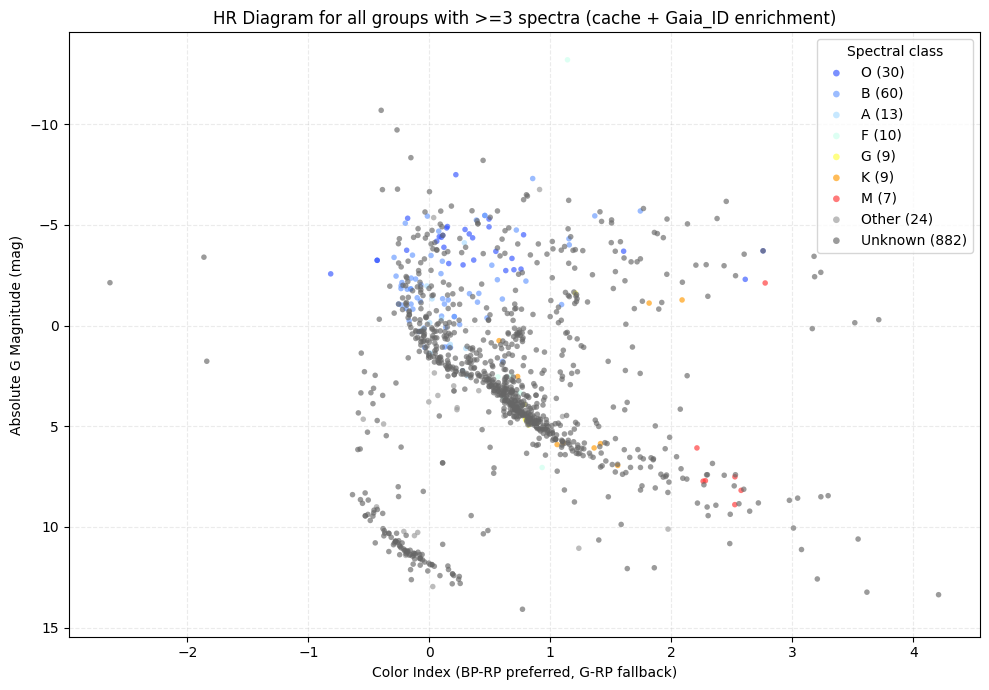

In [13]:
# HR diagram for all groups with >=3 spectra using local Gaia data, with optional Gaia_ID enrichment.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build full target population from metadata: all groups with at least 3 spectra.
if 'meta_resFirst' in globals() and isinstance(meta_resFirst, pd.DataFrame):
    meta_all_qs = meta_resFirst.copy()
else:
    meta_all_qs = pd.read_pickle('/home/msp25gd/Downloads/res/meta/metadata.pkl')

reduced_col_qs = 'Reduced' if 'Reduced' in meta_all_qs.columns else ('reduced' if 'reduced' in meta_all_qs.columns else None)
if reduced_col_qs is None:
    raise KeyError('Could not find Reduced/reduced column in metadata.')

counts_qs = (
    meta_all_qs[reduced_col_qs]
    .astype(str)
    .str.strip()
    .replace({'': np.nan, 'None': np.nan, 'nan': np.nan})
    .dropna()
    .value_counts()
)

all_groups_qs = counts_qs[counts_qs >= 3]
full_groups_qs = pd.DataFrame({
    'Star': all_groups_qs.index.astype(str),
    'n_spectra': all_groups_qs.values.astype(int),
})
full_groups_qs['__key'] = full_groups_qs['Star'].astype(str).str.strip().str.lower()

if full_groups_qs.empty:
    raise ValueError('No groups with >=3 spectra found.')

# Attach spectral types where available from identified_table_resFirst.
if 'identified_table_resFirst' in globals() and isinstance(identified_table_resFirst, pd.DataFrame):
    sp_map_qs = identified_table_resFirst.copy()
    if {'Star', 'SpectralTypeFull'}.issubset(sp_map_qs.columns):
        sp_map_qs = sp_map_qs[['Star', 'SpectralTypeFull']].dropna().copy()
        sp_map_qs['__key'] = sp_map_qs['Star'].astype(str).str.strip().str.lower()
        sp_map_qs = sp_map_qs.drop_duplicates(subset=['__key'])
        full_groups_qs = full_groups_qs.merge(sp_map_qs[['__key', 'SpectralTypeFull']], on='__key', how='left')
    else:
        full_groups_qs['SpectralTypeFull'] = np.nan
else:
    full_groups_qs['SpectralTypeFull'] = np.nan

full_groups_qs['SpectralTypeFull'] = full_groups_qs['SpectralTypeFull'].fillna('Unknown')

# Local Gaia cache files.
groups_candidates = [
    '/home/msp25gd/Downloads/res/meta/groups_w_gaia.pkl',
    '/home/msp25gd/ResearchProjectMSc/HR/groups_w_gaia.pkl',
]
gaia_candidates = [
    '/home/msp25gd/ResearchProjectMSc/HR/gaia-r0_01.pkl',
    '/home/msp25gd/ResearchProjectMSc/HR/search/gaia-r0_01.pkl',
]

groups_path = next((p for p in groups_candidates if os.path.exists(p)), None)
gaia_path = next((p for p in gaia_candidates if os.path.exists(p)), None)
if groups_path is None:
    raise FileNotFoundError(f'Could not find groups_w_gaia.pkl in: {groups_candidates}')
if gaia_path is None:
    raise FileNotFoundError(f'Could not find gaia-r0_01.pkl in: {gaia_candidates}')

groups_df = pd.read_pickle(groups_path).reset_index().rename(columns={'index': 'groups_index'})
gaia_df = pd.read_pickle(gaia_path)

for needed in ['groups_index', 'parallax', 'phot_g_mean_mag']:
    if needed not in gaia_df.columns:
        raise KeyError(f'gaia-r0_01.pkl missing required column: {needed}')

if 'bp_rp' not in gaia_df.columns and 'g_rp' not in gaia_df.columns:
    raise KeyError('gaia-r0_01.pkl must contain bp_rp or g_rp for HR color.')

if 'Reduced' not in groups_df.columns:
    raise KeyError('groups_w_gaia.pkl missing Reduced column for star matching.')
if 'Gaia_ID' not in groups_df.columns:
    raise KeyError('groups_w_gaia.pkl missing Gaia_ID column for enrichment.')

# Match all >=3-spectra groups to groups index, then to Gaia rows.
groups_df['__key'] = groups_df['Reduced'].astype(str).str.strip().str.lower()
groups_map = groups_df[['groups_index', '__key', 'Gaia_ID']].drop_duplicates(subset=['__key'])

work_qs = full_groups_qs.merge(groups_map, on='__key', how='left')
matched_groups_qs = work_qs.dropna(subset=['groups_index']).copy()
matched_groups_qs['groups_index'] = matched_groups_qs['groups_index'].astype(int)

if matched_groups_qs.empty:
    raise ValueError('No >=3-spectra groups matched groups_w_gaia Reduced names.')

# Keep one Gaia row per groups_index from the existing cache.
gaia_small = gaia_df.drop_duplicates(subset=['groups_index'], keep='first').copy()

# Optional backfill: enrich missing groups via Gaia source_id in groups_w_gaia['Gaia_ID'].
enable_gaia_enrichment = True
save_enriched_cache = True
enriched_cache_path = '/home/msp25gd/ResearchProjectMSc/HR/gaia-r0_01_enriched.pkl'
chunk_size = 400
enriched_rows_count = 0
enriched_groups_count = 0

missing_groups = sorted(set(matched_groups_qs['groups_index']) - set(gaia_small['groups_index']))
print(f'Missing groups in base Gaia cache: {len(missing_groups)}')

if enable_gaia_enrichment and len(missing_groups) > 0:
    try:
        from astroquery.gaia import Gaia
    except Exception as ex:
        print(f'Enrichment skipped: astroquery.gaia import failed ({type(ex).__name__}: {ex})')
        Gaia = None

    if Gaia is not None:
        enrich_map = groups_df[groups_df['groups_index'].isin(missing_groups)][['groups_index', 'Gaia_ID']].copy()
        enrich_map['Gaia_ID'] = pd.to_numeric(enrich_map['Gaia_ID'], errors='coerce').astype('Int64')
        enrich_map = enrich_map.dropna(subset=['Gaia_ID']).drop_duplicates(subset=['groups_index'])

        if not enrich_map.empty:
            source_to_group = dict(zip(enrich_map['Gaia_ID'].astype(str), enrich_map['groups_index'].astype(int)))
            source_ids = enrich_map['Gaia_ID'].astype(str).tolist()
            chunk_results = []

            for start in range(0, len(source_ids), chunk_size):
                ids_chunk = source_ids[start:start + chunk_size]
                ids_sql = ','.join(ids_chunk)
                adql = f"""
                    SELECT source_id, phot_g_mean_mag, parallax, parallax_error, bp_rp, ra, dec
                    FROM gaiadr3.gaia_source
                    WHERE source_id IN ({ids_sql})
                """
                try:
                    job = Gaia.launch_job(adql, dump_to_file=False)
                    res = job.get_results()
                    if res is None or len(res) == 0:
                        print(f'Enrichment chunk {start // chunk_size + 1}: no rows returned')
                        continue

                    df_chunk = res.to_pandas() if hasattr(res, 'to_pandas') else pd.DataFrame(res)
                    if df_chunk.empty:
                        print(f'Enrichment chunk {start // chunk_size + 1}: empty dataframe')
                        continue

                    df_chunk['source_id'] = pd.to_numeric(df_chunk['source_id'], errors='coerce').astype('Int64')
                    df_chunk = df_chunk.dropna(subset=['source_id']).copy()
                    df_chunk['groups_index'] = df_chunk['source_id'].astype(str).map(source_to_group)
                    df_chunk = df_chunk.dropna(subset=['groups_index']).copy()
                    df_chunk['groups_index'] = df_chunk['groups_index'].astype(int)

                    chunk_results.append(df_chunk)
                    print(f'Enrichment chunk {start // chunk_size + 1}: +{len(df_chunk)} rows')
                except Exception as ex:
                    print(f'Enrichment chunk {start // chunk_size + 1} failed: {type(ex).__name__}: {ex}')
                    continue

            if len(chunk_results) > 0:
                enriched_df = pd.concat(chunk_results, ignore_index=True)
                enriched_df = enriched_df.drop_duplicates(subset=['groups_index'], keep='first')
                enriched_rows_count = len(enriched_df)
                enriched_groups_count = enriched_df['groups_index'].nunique()

                # Keep existing cache rows if present; only fill truly missing groups.
                gaia_small = pd.concat([gaia_small, enriched_df], ignore_index=True)
                gaia_small = gaia_small.drop_duplicates(subset=['groups_index'], keep='first')

                if save_enriched_cache:
                    try:
                        gaia_small.to_pickle(enriched_cache_path)
                        print(f'Saved enriched Gaia cache to: {enriched_cache_path}')
                    except Exception as ex:
                        print(f'Could not save enriched cache: {type(ex).__name__}: {ex}')
            else:
                print('Enrichment returned no usable rows.')
        else:
            print('Enrichment skipped: no numeric Gaia_ID values available for missing groups.')

merge_cols = ['groups_index', 'source_id', 'phot_g_mean_mag', 'parallax']
if 'parallax_error' in gaia_small.columns:
    merge_cols.append('parallax_error')
if 'bp_rp' in gaia_small.columns:
    merge_cols.append('bp_rp')
if 'g_rp' in gaia_small.columns:
    merge_cols.append('g_rp')

hr_qs = matched_groups_qs.merge(gaia_small[merge_cols], on='groups_index', how='left')

# Prefer BP-RP color; fallback to G-RP.
if 'bp_rp' in hr_qs.columns:
    hr_qs['color_index'] = pd.to_numeric(hr_qs['bp_rp'], errors='coerce')
else:
    hr_qs['color_index'] = np.nan

if 'g_rp' in hr_qs.columns:
    fill_mask = hr_qs['color_index'].isna()
    hr_qs.loc[fill_mask, 'color_index'] = pd.to_numeric(hr_qs.loc[fill_mask, 'g_rp'], errors='coerce')

hr_qs['phot_g_mean_mag'] = pd.to_numeric(hr_qs['phot_g_mean_mag'], errors='coerce')
hr_qs['parallax'] = pd.to_numeric(hr_qs['parallax'], errors='coerce')
if 'parallax_error' in hr_qs.columns:
    hr_qs['parallax_error'] = pd.to_numeric(hr_qs['parallax_error'], errors='coerce')
else:
    hr_qs['parallax_error'] = np.nan

rows_after_gaia_join = len(hr_qs.dropna(subset=['source_id']))
rows_before_filter = len(hr_qs)

# Filter only physically valid plotting points.
hr_qs = hr_qs.dropna(subset=['color_index', 'phot_g_mean_mag', 'parallax']).copy()
hr_qs = hr_qs[hr_qs['parallax'] > 0].copy()

# Keep this relaxed by default so we do not over-prune the >=3-spectra population.
apply_parallax_quality_cut = False
if apply_parallax_quality_cut:
    rel_err = hr_qs['parallax_error'] / hr_qs['parallax']
    hr_qs = hr_qs[(~np.isfinite(rel_err)) | (rel_err <= 0.05)].copy()

if hr_qs.empty:
    raise ValueError('No valid Gaia points left after filtering.')

# Absolute magnitude M_G using parallax in mas.
hr_qs['abs_g'] = hr_qs['phot_g_mean_mag'] + 5.0 * np.log10(hr_qs['parallax']) - 10.0


def _sp_class_qs(sp_full):
    text = str(sp_full).strip().upper()
    if text == '' or text in ['NONE', 'NAN', '--', 'UNKNOWN']:
        return 'Unknown'
    first = text[0]
    return first if first in list('OBAFGKM') else 'Other'


hr_qs['sp_class'] = hr_qs['SpectralTypeFull'].apply(_sp_class_qs)

color_map_qs = {
    'O': '#3355FF',
    'B': '#6699FF',
    'A': '#AADDFF',
    'F': '#CCFFEE',
    'G': '#FFFF44',
    'K': '#FF9900',
    'M': '#FF3333',
    'Other': '#999999',
    'Unknown': '#666666',
}

fig_qs, ax_qs = plt.subplots(figsize=(10, 7))
for cls_qs in ['O', 'B', 'A', 'F', 'G', 'K', 'M', 'Other', 'Unknown']:
    part_qs = hr_qs[hr_qs['sp_class'] == cls_qs]
    if part_qs.empty:
        continue
    ax_qs.scatter(
        part_qs['color_index'],
        part_qs['abs_g'],
        s=16,
        alpha=0.65,
        c=color_map_qs[cls_qs],
        edgecolors='none',
        label=f'{cls_qs} ({len(part_qs)})'
    )

ax_qs.invert_yaxis()
ax_qs.set_xlabel('Color Index (BP-RP preferred, G-RP fallback)')
ax_qs.set_ylabel('Absolute G Magnitude (mag)')
ax_qs.set_title('HR Diagram for all groups with >=3 spectra (cache + Gaia_ID enrichment)')
ax_qs.grid(alpha=0.25, linestyle='--')
ax_qs.legend(title='Spectral class', loc='best', frameon=True, markerscale=1.2)

print(f'Local groups file: {groups_path}')
print(f'Base Gaia file: {gaia_path}')
print(f'Total groups with >=3 spectra: {len(full_groups_qs)}')
print(f'Groups matched to groups_w_gaia index: {matched_groups_qs["Star"].nunique()}')
print(f'Enriched Gaia rows added: {enriched_rows_count} (groups: {enriched_groups_count})')
print(f'Rows with Gaia source match after enrichment: {rows_after_gaia_join}')
print(f'Rows before plotting filters: {rows_before_filter}')
print(f'Plotted points: {len(hr_qs)}')
print(f'Groups with known spectral type: {(full_groups_qs["SpectralTypeFull"] != "Unknown").sum()}')

plt.tight_layout()
plt.show()

Stylish HR scatter (no color map):
  color_index range: [-0.664, 2.719]
  abs_g range:       [-6.654, 12.901] (inverted axis)
  points shown:      1044
  saving to:         /home/msp25gd/ResearchProjectMSc/Images/finalOtherImages/HR_diagram_stylish.png


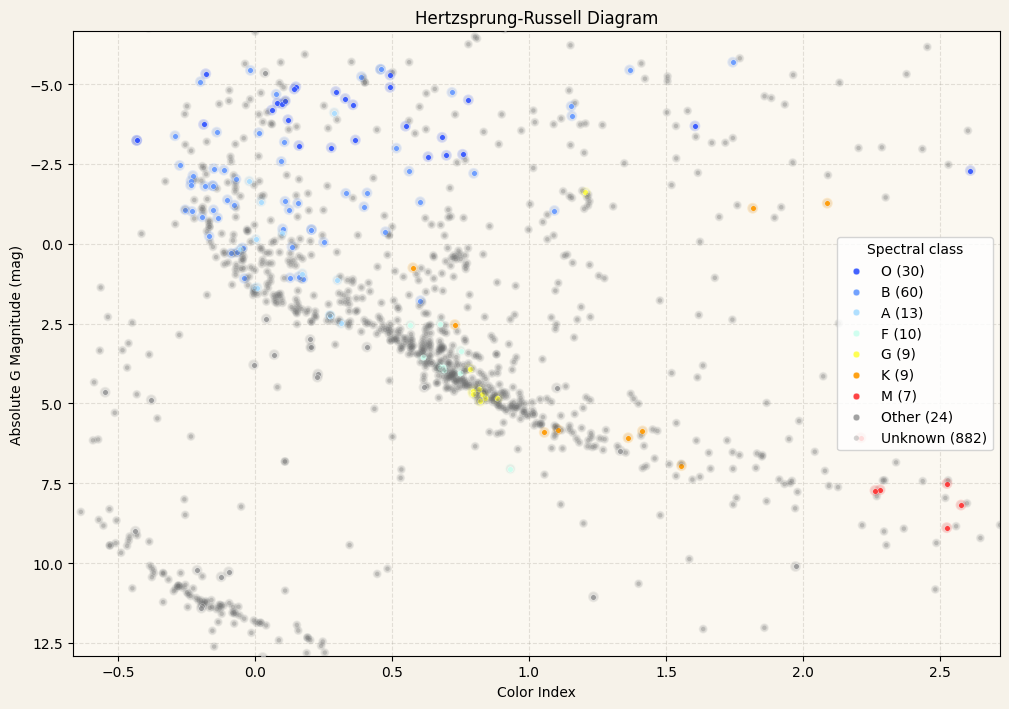

In [23]:
# Stylish HR view (no color map): layered scatter only.
import os
import numpy as np
import matplotlib.pyplot as plt

if 'hr_qs' not in globals() or hr_qs is None or len(hr_qs) == 0:
    raise RuntimeError('hr_qs is not available. Run the HR plotting cell above first.')

if 'color_map_qs' not in globals():
    color_map_qs = {
        'O': '#3355FF',
        'B': '#6699FF',
        'A': '#AADDFF',
        'F': '#CCFFEE',
        'G': '#FFFF44',
        'K': '#FF9900',
        'M': '#FF3333',
        'Other': '#999999',
        'Unknown': '#666666',
    }

# Focus on dense center while keeping a little breathing room.
x_lo, x_hi = np.nanpercentile(hr_qs['color_index'], [3, 97])
y_lo, y_hi = np.nanpercentile(hr_qs['abs_g'], [3, 97])
x_pad = max(0.05, 0.08 * (x_hi - x_lo))
y_pad = max(0.20, 0.08 * (y_hi - y_lo))

fig_sq, ax_sq = plt.subplots(figsize=(10.2, 7.2))
fig_sq.patch.set_facecolor('#f6f2e9')
ax_sq.set_facecolor('#fbf8f1')

# Soft base cloud for atmosphere (all stars, very faint).
ax_sq.scatter(
    hr_qs['color_index'],
    hr_qs['abs_g'],
    s=42,
    c='#2f3b45',
    alpha=0.07,
    edgecolors='none',
    zorder=1
)

# Spectral-class overlays with subtle glow + crisp center point.
for cls_qs in ['O', 'B', 'A', 'F', 'G', 'K', 'M', 'Other', 'Unknown']:
    part_qs = hr_qs[hr_qs['sp_class'] == cls_qs]
    if part_qs.empty:
        continue

    if cls_qs == 'Unknown':
        glow_size, core_size = 28, 10
        glow_alpha, core_alpha = 0.12, 0.28
        edge_col, lw = 'none', 0.0
    else:
        glow_size, core_size = 62, 16
        glow_alpha, core_alpha = 0.16, 0.92
        edge_col, lw = 'white', 0.26

    # Glow layer.
    ax_sq.scatter(
        part_qs['color_index'],
        part_qs['abs_g'],
        s=glow_size,
        c=color_map_qs.get(cls_qs, '#666666'),
        alpha=glow_alpha,
        edgecolors='none',
        zorder=2
    )

    # Core layer.
    ax_sq.scatter(
        part_qs['color_index'],
        part_qs['abs_g'],
        s=core_size,
        c=color_map_qs.get(cls_qs, '#666666'),
        alpha=core_alpha,
        edgecolors=edge_col,
        linewidths=lw,
        label=f'{cls_qs} ({len(part_qs)})',
        zorder=3
    )

ax_sq.invert_yaxis()
ax_sq.set_xlim(x_lo - x_pad, x_hi + x_pad)
ax_sq.set_ylim(y_hi + y_pad, y_lo - y_pad)

ax_sq.set_xlabel('Color Index')
ax_sq.set_ylabel('Absolute G Magnitude (mag)')
ax_sq.set_title('Hertzsprung-Russell Diagram')
ax_sq.grid(alpha=0.22, linestyle='--', color='#8b857a')
ax_sq.legend(title='Spectral class', loc='best', frameon=True, framealpha=0.82, markerscale=1.2)

output_dir = '/home/msp25gd/ResearchProjectMSc/Images/finalOtherImages'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'HR_diagram_stylish.png')

print('Stylish HR scatter (no color map):')
print(f'  color_index range: [{x_lo - x_pad:.3f}, {x_hi + x_pad:.3f}]')
print(f'  abs_g range:       [{y_lo - y_pad:.3f}, {y_hi + y_pad:.3f}] (inverted axis)')
print(f'  points shown:      {len(hr_qs)}')
print(f'  saving to:         {output_path}')

plt.tight_layout()
fig_sq.savefig(output_path, dpi=220, bbox_inches='tight', facecolor=fig_sq.get_facecolor())
plt.show()

Density-nebula view ready (same 1044 points, density-emphasized).


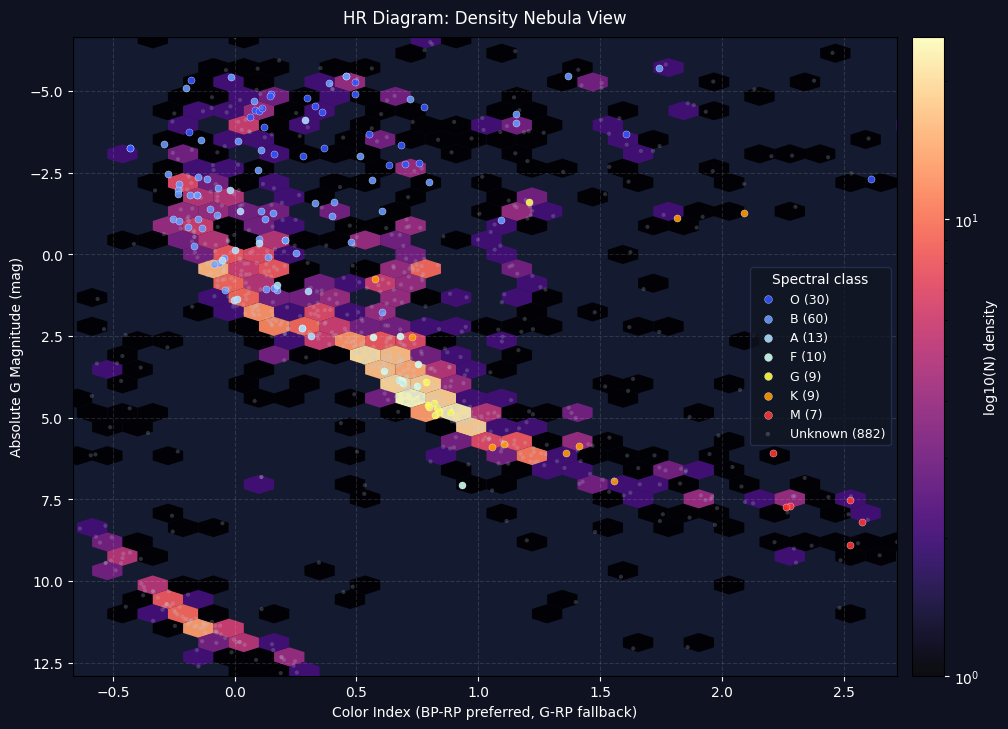

In [17]:
# Alternative cool visualization: density-nebula HR diagram (hexbin + spectral highlights).
import numpy as np
import matplotlib.pyplot as plt

if 'hr_qs' not in globals() or hr_qs is None or len(hr_qs) == 0:
    raise RuntimeError('hr_qs is not available. Run the HR plotting cell above first.')

# Reuse squished window for consistency.
x_lo, x_hi = np.nanpercentile(hr_qs['color_index'], [3, 97])
y_lo, y_hi = np.nanpercentile(hr_qs['abs_g'], [3, 97])
x_pad = max(0.05, 0.08 * (x_hi - x_lo))
y_pad = max(0.20, 0.08 * (y_hi - y_lo))

fig_alt, ax_alt = plt.subplots(figsize=(10.8, 7.4))
fig_alt.patch.set_facecolor('#0f1221')
ax_alt.set_facecolor('#141a2f')

# Dense background structure.
hb = ax_alt.hexbin(
    hr_qs['color_index'],
    hr_qs['abs_g'],
    gridsize=55,
    cmap='magma',
    bins='log',
    mincnt=1,
    linewidths=0.0,
    alpha=0.95
)
cb = fig_alt.colorbar(hb, ax=ax_alt, pad=0.015)
cb.set_label('log10(N) density', color='white')
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(cb.ax.get_yticklabels(), color='white')

# Highlight known spectral classes on top.
highlight_classes = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
for cls in highlight_classes:
    part = hr_qs[hr_qs['sp_class'] == cls]
    if part.empty:
        continue
    ax_alt.scatter(
        part['color_index'],
        part['abs_g'],
        s=26,
        alpha=0.90,
        c=color_map_qs.get(cls, '#ffffff'),
        edgecolors='white',
        linewidths=0.25,
        label=f'{cls} ({len(part)})'
    )

# Keep unknowns subtle so structure remains visible.
unknown_part = hr_qs[hr_qs['sp_class'] == 'Unknown']
if not unknown_part.empty:
    ax_alt.scatter(
        unknown_part['color_index'],
        unknown_part['abs_g'],
        s=9,
        alpha=0.22,
        c='#c7cfdd',
        edgecolors='none',
        label=f'Unknown ({len(unknown_part)})'
    )

ax_alt.invert_yaxis()
ax_alt.set_xlim(x_lo - x_pad, x_hi + x_pad)
ax_alt.set_ylim(y_hi + y_pad, y_lo - y_pad)

ax_alt.set_xlabel('Color Index (BP-RP preferred, G-RP fallback)', color='white')
ax_alt.set_ylabel('Absolute G Magnitude (mag)', color='white')
ax_alt.set_title('HR Diagram: Density Nebula View', color='white', pad=10)
ax_alt.grid(alpha=0.12, linestyle='--', color='white')
ax_alt.tick_params(colors='white')

legend = ax_alt.legend(
    title='Spectral class',
    loc='best',
    frameon=True,
    framealpha=0.75,
    facecolor='#111522',
    edgecolor='#2a3355',
    fontsize=9,
    title_fontsize=10,
    markerscale=1.1
)
plt.setp(legend.get_texts(), color='white')
legend.get_title().set_color('white')

print('Density-nebula view ready (same 1044 points, density-emphasized).')
plt.tight_layout()
plt.show()

Contour atlas view ready.
KDE mode: True


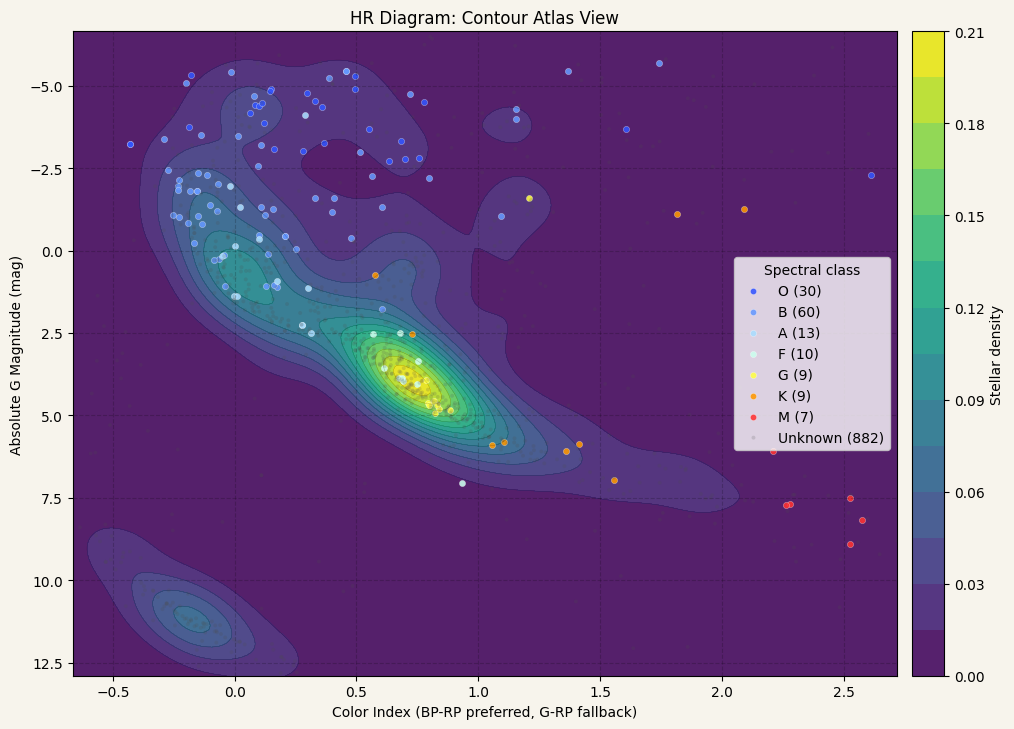

In [18]:
# Alternative style: smooth contour-density HR map with spectral overlays.
import numpy as np
import matplotlib.pyplot as plt

if 'hr_qs' not in globals() or hr_qs is None or len(hr_qs) == 0:
    raise RuntimeError('hr_qs is not available. Run the HR plotting cell above first.')

# Focus on the same dense window for comparability.
x_lo, x_hi = np.nanpercentile(hr_qs['color_index'], [3, 97])
y_lo, y_hi = np.nanpercentile(hr_qs['abs_g'], [3, 97])
x_pad = max(0.05, 0.08 * (x_hi - x_lo))
y_pad = max(0.20, 0.08 * (y_hi - y_lo))

x_min, x_max = x_lo - x_pad, x_hi + x_pad
y_min, y_max = y_lo - y_pad, y_hi + y_pad

x = hr_qs['color_index'].to_numpy()
y = hr_qs['abs_g'].to_numpy()
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# Build a smooth density field.
grid_n = 220
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, grid_n),
    np.linspace(y_min, y_max, grid_n)
)

used_kde = False
try:
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(np.vstack([x, y]), bw_method=0.16)
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    used_kde = True
except Exception:
    # Fallback if scipy is unavailable.
    hist, xedges, yedges = np.histogram2d(x, y, bins=90, range=[[x_min, x_max], [y_min, y_max]])
    hist = hist.T
    from scipy.ndimage import gaussian_filter
    zz = gaussian_filter(hist, sigma=1.3)
    xx, yy = np.meshgrid(
        0.5 * (xedges[:-1] + xedges[1:]),
        0.5 * (yedges[:-1] + yedges[1:])
)

fig_ct, ax_ct = plt.subplots(figsize=(10.8, 7.4))
fig_ct.patch.set_facecolor('#f7f4ec')
ax_ct.set_facecolor('#f3efe4')

# Filled contours + line contours for a polished map look.
levels = 14 if used_kde else 10
cf = ax_ct.contourf(xx, yy, zz, levels=levels, cmap='viridis', alpha=0.92)
ax_ct.contour(xx, yy, zz, levels=levels, colors='black', linewidths=0.28, alpha=0.32)
cb = fig_ct.colorbar(cf, ax=ax_ct, pad=0.015)
cb.set_label('Stellar density')

# Overlay spectral classes (small crisp markers).
for cls in ['O', 'B', 'A', 'F', 'G', 'K', 'M']:
    part = hr_qs[hr_qs['sp_class'] == cls]
    if part.empty:
        continue
    ax_ct.scatter(
        part['color_index'],
        part['abs_g'],
        s=20,
        alpha=0.88,
        c=color_map_qs.get(cls, '#111111'),
        edgecolors='white',
        linewidths=0.22,
        label=f'{cls} ({len(part)})'
    )

# Unknown stars are intentionally faint.
unknown_part = hr_qs[hr_qs['sp_class'] == 'Unknown']
if not unknown_part.empty:
    ax_ct.scatter(
        unknown_part['color_index'],
        unknown_part['abs_g'],
        s=8,
        alpha=0.18,
        c='#4d4d4d',
        edgecolors='none',
        label=f'Unknown ({len(unknown_part)})'
    )

ax_ct.invert_yaxis()
ax_ct.set_xlim(x_min, x_max)
ax_ct.set_ylim(y_max, y_min)
ax_ct.set_xlabel('Color Index (BP-RP preferred, G-RP fallback)')
ax_ct.set_ylabel('Absolute G Magnitude (mag)')
ax_ct.set_title('HR Diagram: Contour Atlas View')
ax_ct.grid(alpha=0.18, linestyle='--', color='black')
ax_ct.legend(title='Spectral class', loc='best', frameon=True, framealpha=0.80, markerscale=1.0)

print('Contour atlas view ready.')
print(f'KDE mode: {used_kde}')
plt.tight_layout()
plt.show()

In [9]:
# Quick test from scratch: 10 stars with hard per-query timeout (Gaia-safe).
import time
import multiprocessing as mp
import numpy as np
import pandas as pd
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u

if 'identified_table_resFirst' not in globals() or not isinstance(identified_table_resFirst, pd.DataFrame):
    raise RuntimeError('identified_table_resFirst is missing. Run Cell 6 first.')

sp_test = identified_table_resFirst[['Star', 'SpectralTypeFull']].dropna().copy()
sp_test['Star'] = sp_test['Star'].astype(str).str.strip()
sp_test = sp_test[sp_test['Star'] != ''].drop_duplicates(subset=['Star']).head(10).reset_index(drop=True)

if sp_test.empty:
    raise ValueError('No stars available in identified_table_resFirst for test run.')

if 'meta_resFirst' in globals() and isinstance(meta_resFirst, pd.DataFrame):
    meta_test = meta_resFirst.copy()
else:
    meta_test = pd.read_pickle('/home/msp25gd/Downloads/res/meta/metadata.pkl')

reduced_col = 'Reduced' if 'Reduced' in meta_test.columns else ('reduced' if 'reduced' in meta_test.columns else None)
if reduced_col is None:
    raise KeyError('Could not find Reduced/reduced column in metadata.')

ra_candidates = ['RA', 'ra', 'RAJ2000', 'raj2000', '_RAJ2000', 'ALPHA_J2000', 'RA_ICRS', 'RA_ICRS_deg']
dec_candidates = ['DEC', 'Dec', 'dec', 'DEJ2000', 'dej2000', '_DEJ2000', 'DELTA_J2000', 'DEC_ICRS', 'DEC_ICRS_deg']
ra_col = next((c for c in ra_candidates if c in meta_test.columns), None)
dec_col = next((c for c in dec_candidates if c in meta_test.columns), None)
if ra_col is None or dec_col is None:
    raise KeyError(f'No usable RA/Dec columns found. RA={ra_col}, Dec={dec_col}')

meta_small = meta_test[[reduced_col, ra_col, dec_col]].copy()
meta_small['__key'] = meta_small[reduced_col].astype(str).str.strip().str.lower()
meta_small = meta_small.drop_duplicates(subset=['__key'])

sp_test['__key'] = sp_test['Star'].astype(str).str.strip().str.lower()
work = sp_test.merge(meta_small[['__key', ra_col, dec_col]], on='__key', how='left')


def _to_deg_pair(ra_value, dec_value):
    if pd.isna(ra_value) or pd.isna(dec_value):
        return (np.nan, np.nan)

    ra_text = str(ra_value).strip()
    dec_text = str(dec_value).strip()
    if ra_text in ['', 'None', 'nan'] or dec_text in ['', 'None', 'nan']:
        return (np.nan, np.nan)

    try:
        c = SkyCoord(float(ra_text) * u.deg, float(dec_text) * u.deg, frame='icrs')
        return (float(c.ra.deg), float(c.dec.deg))
    except Exception:
        pass

    try:
        c = SkyCoord(ra_text, dec_text, unit=(u.hourangle, u.deg), frame='icrs')
        return (float(c.ra.deg), float(c.dec.deg))
    except Exception:
        pass

    try:
        c = SkyCoord(ra_text, dec_text, unit=(u.deg, u.deg), frame='icrs')
        return (float(c.ra.deg), float(c.dec.deg))
    except Exception:
        return (np.nan, np.nan)


def _gaia_query_worker(ra_deg, dec_deg, out_q):
    try:
        Gaia.ROW_LIMIT = 1
        adql = f"""
            SELECT TOP 1 source_id, bp_rp, phot_g_mean_mag, parallax
            FROM gaiadr3.gaia_source
            WHERE CONTAINS(
                POINT('ICRS', gaiadr3.gaia_source.ra, gaiadr3.gaia_source.dec),
                CIRCLE('ICRS', {ra_deg}, {dec_deg}, {2.0/3600.0})
            ) = 1
            ORDER BY DISTANCE(
                POINT('ICRS', gaiadr3.gaia_source.ra, gaiadr3.gaia_source.dec),
                POINT('ICRS', {ra_deg}, {dec_deg})
            ) ASC
        """
        res = Gaia.launch_job(adql, dump_to_file=False).get_results()
        if res is None or len(res) == 0:
            out_q.put({'status': 'no_match'})
            return
        rec = res[0]
        out_q.put({
            'status': 'ok',
            'source_id': rec['source_id'],
            'bp_rp': rec['bp_rp'],
            'phot_g_mean_mag': rec['phot_g_mean_mag'],
            'parallax': rec['parallax'],
        })
    except Exception as ex:
        out_q.put({'status': 'error', 'error_type': type(ex).__name__})


coords = work.apply(lambda r: _to_deg_pair(r.get(ra_col), r.get(dec_col)), axis=1)
work['ra_deg'] = [x[0] for x in coords]
work['dec_deg'] = [x[1] for x in coords]

print(f'Input stars: {len(work)}')

rows = []
skipped_coord = 0
no_match = 0
errors = 0
timeouts = 0

per_query_timeout_sec = 15
print(f'Per-query hard timeout: {per_query_timeout_sec}s')

for i, row in work.iterrows():
    star = row['Star']
    ra_deg = row['ra_deg']
    dec_deg = row['dec_deg']
    print(f'[{time.strftime("%H:%M:%S")}] {i + 1}/{len(work)}: {star}')

    if not np.isfinite(ra_deg) or not np.isfinite(dec_deg):
        skipped_coord += 1
        print('  -> skipped: no usable coordinate')
        continue

    q = mp.Queue()
    p = mp.Process(target=_gaia_query_worker, args=(float(ra_deg), float(dec_deg), q))
    p.start()
    p.join(per_query_timeout_sec)

    if p.is_alive():
        p.terminate()
        p.join(2)
        timeouts += 1
        print('  -> timeout: Gaia query killed')
        continue

    payload = q.get() if not q.empty() else {'status': 'error', 'error_type': 'NoPayload'}
    status = payload.get('status')

    if status == 'ok':
        rows.append({
            'Star': star,
            'SpectralTypeFull': row['SpectralTypeFull'],
            'source_id': payload.get('source_id'),
            'bp_rp': payload.get('bp_rp'),
            'phot_g_mean_mag': payload.get('phot_g_mean_mag'),
            'parallax': payload.get('parallax'),
        })
        print('  -> Gaia match found')
    elif status == 'no_match':
        no_match += 1
        print('  -> no Gaia match')
    else:
        errors += 1
        print(f"  -> Gaia error: {payload.get('error_type', 'Unknown')}")

quick_test_hr_df = pd.DataFrame(rows)

print('\nQuick test summary:')
print(f'Input stars: {len(work)}')
print(f'Gaia matches: {len(quick_test_hr_df)}')
print(f'Skipped (bad coord): {skipped_coord}')
print(f'No Gaia match: {no_match}')
print(f'Query errors: {errors}')
print(f'Timeouts: {timeouts}')

if len(quick_test_hr_df) > 0:
    display(quick_test_hr_df)

Input stars: 10
Per-query hard timeout: 15s
[05:58:03] 1/10: betpic
  -> timeout: Gaia query killed
[05:58:18] 2/10: eg21
  -> timeout: Gaia query killed
[05:58:33] 3/10: hd10638


Process Process-3:
Traceback (most recent call last):
  File "/usr/local/python-3.12/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/local/python-3.12/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_287102/1748696161.py", line 87, in _gaia_query_worker
    res = Gaia.launch_job(adql, dump_to_file=False).get_results()
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/msp25gd/.local/lib/python3.12/site-packages/astroquery/gaia/core.py", line 1104, in launch_job
    return TapPlus.launch_job(self, query=query, name=name,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/msp25gd/.local/lib/python3.12/site-packages/astroquery/utils/tap/core.py", line 309, in launch_job
    response = self.__launchJob(query=query,
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/msp25gd/.local/lib/python3.12/site-packages/astroquer

KeyboardInterrupt: 

  File "/home/msp25gd/.local/lib/python3.12/site-packages/astroquery/utils/tap/conn/tapconn.py", line 423, in __execute_post
    response = conn.getresponse()
               ^^^^^^^^^^^^^^^^^^
  File "/usr/local/python-3.12/lib/python3.12/http/client.py", line 1450, in getresponse
    response.begin()
  File "/usr/local/python-3.12/lib/python3.12/http/client.py", line 336, in begin
    version, status, reason = self._read_status()
                              ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/python-3.12/lib/python3.12/http/client.py", line 297, in _read_status
    line = str(self.fp.readline(_MAXLINE + 1), "iso-8859-1")
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/python-3.12/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/python-3.12/lib/python3.12/ssl.py", line 1251, in recv_into
    return self.read(nbytes, buffer)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/loc